# NB03c3 — Biomarker EDA: Hopanes, Steranes & Terpanes

Analyzes 21 biomarker compounds (12 hopanes, 6 terpanes, 3 steranes) from ECCC ESTS.
Biomarkers are thermally resistant (BP >400°C) and should be **perfectly stable**
under 80°C rotary evaporation — pure identity markers for oil source identification.

**Depends on:** NB01 (measurements), NB02 (diagnostic_ratios)
**Produces:** Biomarker stability confirmation, oil-type discrimination, ~12 figures

In [1]:
# C01 -- Setup
import sys, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats
from scipy.stats import wilcoxon, kruskal, spearmanr, mannwhitneyu
from IPython.display import display, Image
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'notebooks'))
from utils import get_conn, STAGE_COLORS, OILTYPE_COLORS, setup_figure_style, FIG_ROOT

setup_figure_style()
import matplotlib as _mpl
_mpl.rcParams['font.family'] = 'DejaVu Sans'

FIG_DIR = FIG_ROOT / 'nb03c3'
if FIG_DIR.exists():
    shutil.rmtree(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

STAGE_ORDER = ['W0', 'W1', 'W2', 'W3']
OIL_TYPES_ML = ['crude', 'bitumen_blend', 'refined', 'synthetic']

# Biomarker compound definitions (from database inventory)
HOPANES = {
    'H29':  '30-Norhopane (H29)',
    'H30':  'Hopane (H30)',
    'H31S': '30-Homohopane-22S (H31S)',
    'H31R': '30-Homohopane-22R (H31R)',
    'H32S': '30,31-Bishomohopane-22S (H32S)',
    'H32R': '30,31-Bishomohopane-22R (H32R)',
    'H33S': '30,31-Trishomohopane-22S (H33S)',
    'H33R': '30,31-Trishomohopane-22R (H33R)',
    'H34S': 'Tetrakishomohopane-22S (H34S)',
    'H34R': 'Tetrakishomohopane-22R (H34R)',
    'H35S': 'Pentakishomohopane-22S (H35S)',
    'H35R': 'Pentakishomohopane-22R (H35R)',
}

TERPANES = {
    'Tm':   '17a(H)-22,29,30-Trisnorhopane (C27Tm)',
    'Ts':   '18a,22,29,30-trisnorneohopane (C27Ts)',
    'C21T': 'C21 tricyclic terpane (C21T)',
    'C22T': 'C22 tricyclic terpane (C22T)',
    'C23T': 'C23 tricyclic terpane (C23T)',
    'C24T': 'C24 tricyclic terpane (C24T)',
}

STERANES = {
    # F-NB03c3-C1 (28/abr/2026): canonical ß per CHG-0006/F-NB01-C1 fix.
    # Pre-fix used 'ss' transliteration which silently broke string-match
    # against compounds.compound_name (cascade from F-NB01-C1 → F-NB02-C1).
    'C27':  '14ß(H),17ß(H)-20-Cholestane (C27aßß)',
    'C28':  '20-Methyl-14ß(H),17ß(H)-Cholestane (C28aßß)',
    'C29':  '20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)',
}

ALL_BIOMARKERS = {**HOPANES, **TERPANES, **STERANES}

# Identity ratios involving biomarkers
IDENTITY_RATIOS = ['Ts_Tm', 'H29_H30', 'H31S_H31R', 'H32S_H32R', 'C23T_C24T']

print(f'Setup OK | {len(ALL_BIOMARKERS)} biomarker compounds | FIG_DIR: {FIG_DIR}')

Setup OK | 21 biomarker compounds | FIG_DIR: C:\Users\leogr\Documents\Data Science\TCC\figures\nb03c3


## Prerequisites — defense-in-depth guard (F-NB03c3-C2 → F-UTILS-1)

Sterane-specific guard consolidated into `utils.assert_sterane_canonical_in_db()`
(F-UTILS-1, 28/abr/2026). Covers F-NB01-C1 (ß spelling) + FIX-NB00-1 (triggers) +
CHG-0007 (sterane ratios canonical). The broader 21-biomarker presence check
(hopanes + terpanes — never part of the F-NB01-C1 cascade) stays inline below.


In [ ]:
# F-UTILS-1 (28/abr/2026): consolidated sterane guard.
# Replaces the sterane-specific portion of the inline F-NB03c3-C2 guard.
from utils import assert_sterane_canonical_in_db
assert_sterane_canonical_in_db()

# Broader biomarker presence check (18 hopanes + terpanes that were never
# part of F-NB01-C1 cascade). Kept inline as it is NB03c3-specific.
_NON_STERANE_BIOMARKERS = {
    name: cname for d in (HOPANES, TERPANES) for name, cname in d.items()
}
with get_conn() as conn:
    placeholders = ','.join(['?'] * len(_NON_STERANE_BIOMARKERS))
    rows = conn.execute(
        f"SELECT compound_name FROM compounds WHERE compound_name IN ({placeholders})",
        list(_NON_STERANE_BIOMARKERS.values()),
    ).fetchall()
present = {r[0] for r in rows}
missing = set(_NON_STERANE_BIOMARKERS.values()) - present
assert not missing, (
    f'NB03c3 prerequisite failed — non-sterane biomarkers missing: {sorted(missing)}.'
)
print(f'✓ NB03c3 non-sterane biomarkers in DB: {len(present)}/{len(_NON_STERANE_BIOMARKERS)}')


## Part 1 — Data Inventory and Missingness

In [3]:
# C02 -- Load all biomarker measurements
compound_names = list(ALL_BIOMARKERS.values())
placeholders = ','.join('?' * len(compound_names))

with get_conn() as conn:
    df_bio = pd.read_sql(f"""
        SELECT m.oil_id, o.oil_name, o.oil_type, m.stage_code AS stage,
               c.compound_name, m.value_raw AS intensity, m.is_nd
        FROM measurements m
        JOIN compounds c ON m.compound_id = c.compound_id
        JOIN oils o ON m.oil_id = o.oil_id
        WHERE c.compound_name IN ({placeholders})
          AND o.include_in_analysis = 1
    """, conn, params=compound_names)

# Create abbreviation column
name_to_abbrev = {v: k for k, v in ALL_BIOMARKERS.items()}
df_bio['abbrev'] = df_bio['compound_name'].map(name_to_abbrev)

# Tag compound class
hopane_names = set(HOPANES.values())
terpane_names = set(TERPANES.values())
sterane_names = set(STERANES.values())
df_bio['bio_class'] = df_bio['compound_name'].apply(
    lambda x: 'hopane' if x in hopane_names else 'terpane' if x in terpane_names else 'sterane')

print(f'Loaded {len(df_bio):,} biomarker measurements')
print(f'Oils: {df_bio["oil_id"].nunique()}, Compounds: {df_bio["compound_name"].nunique()}')
print(f'\nRecords per class:')
print(df_bio.groupby('bio_class')['compound_name'].nunique().to_string())

Loaded 5,397 biomarker measurements
Oils: 62, Compounds: 21

Records per class:
bio_class
hopane     12
sterane     3
terpane     6


In [4]:
# C03 -- Missingness analysis by oil_type
# For each oil_type x compound: % of oil×stage combos with is_nd=1 or intensity<=0
df_bio['is_missing'] = (df_bio['is_nd'] == 1) | (df_bio['intensity'] <= 0) | df_bio['intensity'].isna()

miss_pct = df_bio.groupby(['oil_type', 'abbrev'])['is_missing'].mean().unstack(level=0) * 100
# Reorder columns
miss_pct = miss_pct.reindex(columns=[ot for ot in OIL_TYPES_ML if ot in miss_pct.columns])

# Reorder rows by class then name
class_order = {'Tm': 0, 'Ts': 1, 'C21T': 2, 'C22T': 3, 'C23T': 4, 'C24T': 5,
               'H29': 10, 'H30': 11, 'H31S': 12, 'H31R': 13, 'H32S': 14, 'H32R': 15,
               'H33S': 16, 'H33R': 17, 'H34S': 18, 'H34R': 19, 'H35S': 20, 'H35R': 21,
               'C27': 30, 'C28': 31, 'C29': 32}
miss_pct = miss_pct.loc[sorted(miss_pct.index, key=lambda x: class_order.get(x, 99))]

print('Missingness (% ND or zero) by oil_type:')
print(miss_pct.round(1).to_string())

Missingness (% ND or zero) by oil_type:
oil_type  crude  bitumen_blend  refined  synthetic
abbrev                                            
Tm         17.0           17.5     32.3        0.0
Ts         17.0           17.5     22.6        0.0
C21T       27.3           22.5     12.9        0.0
C22T       27.3           22.5     12.9        0.0
C23T       17.0           17.5      6.5        0.0
C24T       17.0           17.5      6.5        0.0
H29        17.0           17.5     12.9        0.0
H30        17.0           17.5     12.9        0.0
H31S       17.0           17.5     61.3        0.0
H31R       17.0           17.5     61.3        0.0
H32S       17.0           17.5     61.3        0.0
H32R       17.0           17.5     83.9        0.0
H33S       17.0           17.5     83.9        0.0
H33R       17.0           17.5    100.0        0.0
H34S       17.0           17.5    100.0        0.0
H34R       17.0           17.5     96.8        0.0
H35S       27.3           22.5    100.0   

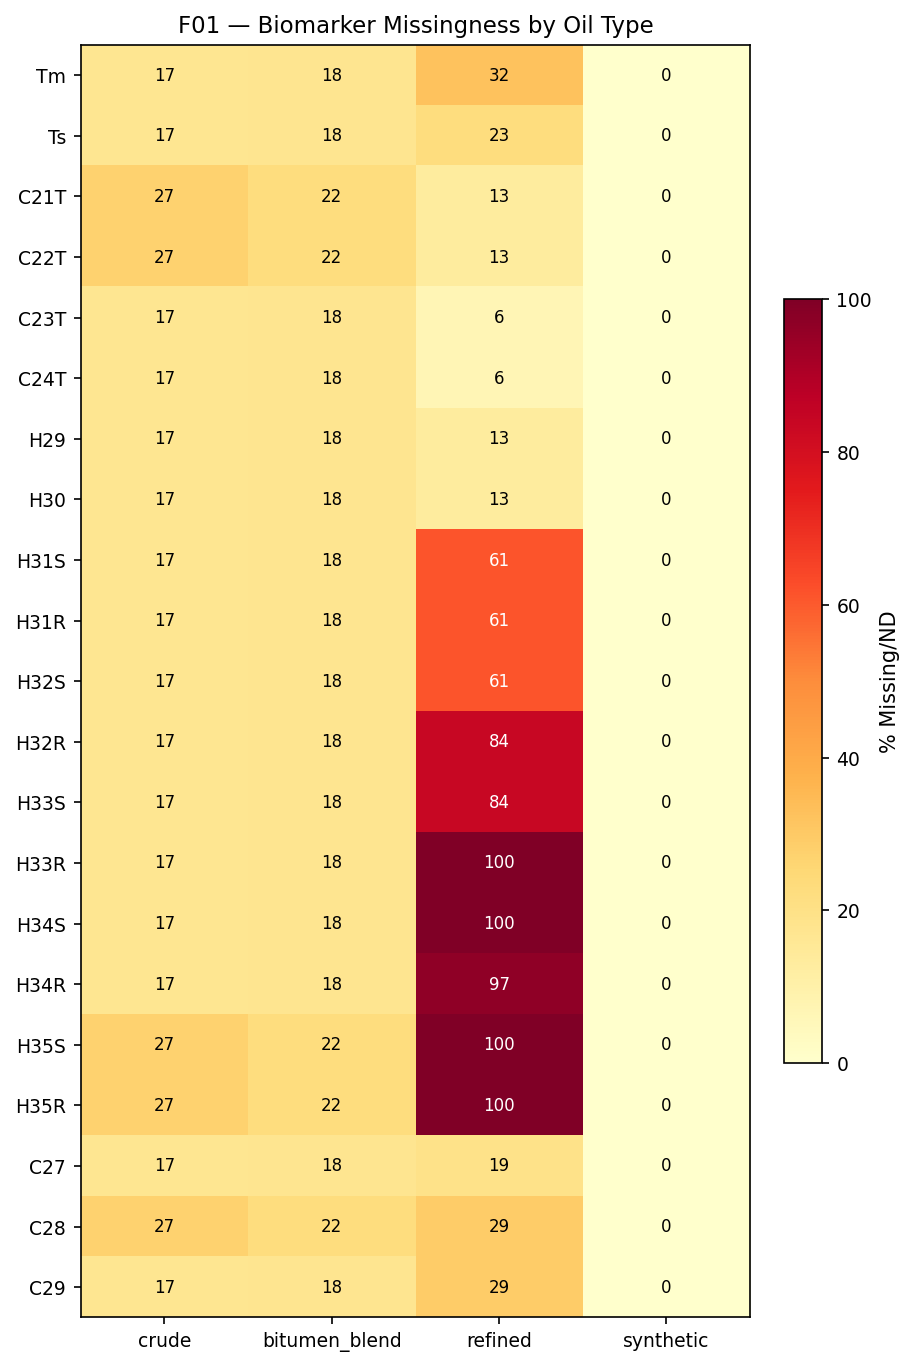


Compounds with >50% valid measurements: 21/21


In [5]:
# F01 -- Missingness heatmap
fig, ax = plt.subplots(figsize=(6, 9), constrained_layout=True)
im = ax.imshow(miss_pct.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
ax.set_xticks(range(len(miss_pct.columns)))
ax.set_xticklabels(miss_pct.columns, fontsize=9)
ax.set_yticks(range(len(miss_pct.index)))
ax.set_yticklabels(miss_pct.index, fontsize=9)
# Annotate cells
for i in range(len(miss_pct.index)):
    for j in range(len(miss_pct.columns)):
        val = miss_pct.iloc[i, j]
        color = 'white' if val > 50 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8, color=color)
cb = fig.colorbar(im, ax=ax, shrink=0.6, label='% Missing/ND')
ax.set_title('F01 — Biomarker Missingness by Oil Type', fontsize=11)
fig_path = FIG_DIR / 'F01_biomarker_missingness_heatmap.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# Summary
n_valid = df_bio.groupby('abbrev').apply(lambda g: (g['is_missing'] == False).sum())
print(f'\nCompounds with >50% valid measurements: {(n_valid > 0.5 * n_valid.max()).sum()}/{len(ALL_BIOMARKERS)}')

## Part 2 — Hopane Fingerprint

In [6]:
# C04 -- Hopane fingerprint: all compounds normalized to H30
# Order: H29, H30, H31S, H31R, H32S, H32R, H33S, H33R, H34S, H34R, H35S, H35R
HOPANE_ORDER = ['H29', 'H30', 'H31S', 'H31R', 'H32S', 'H32R',
                'H33S', 'H33R', 'H34S', 'H34R', 'H35S', 'H35R']

df_hop = df_bio[df_bio['bio_class'] == 'hopane'].copy()
# Pivot to wide: rows = oil×stage, columns = hopane abbreviations
hop_wide = df_hop.pivot_table(index=['oil_id', 'oil_type', 'stage'],
                               columns='abbrev', values='intensity')

# Normalize to H30 = 1.0
for col in hop_wide.columns:
    if col != 'H30':
        hop_wide[col] = hop_wide[col] / hop_wide['H30'].replace(0, np.nan)
hop_wide['H30'] = 1.0

hop_wide = hop_wide.reindex(columns=HOPANE_ORDER)
hop_wide = hop_wide.reset_index()
print(f'Hopane fingerprint matrix: {len(hop_wide)} oil x stage combos, {len(HOPANE_ORDER)} compounds')

Hopane fingerprint matrix: 216 oil x stage combos, 12 compounds


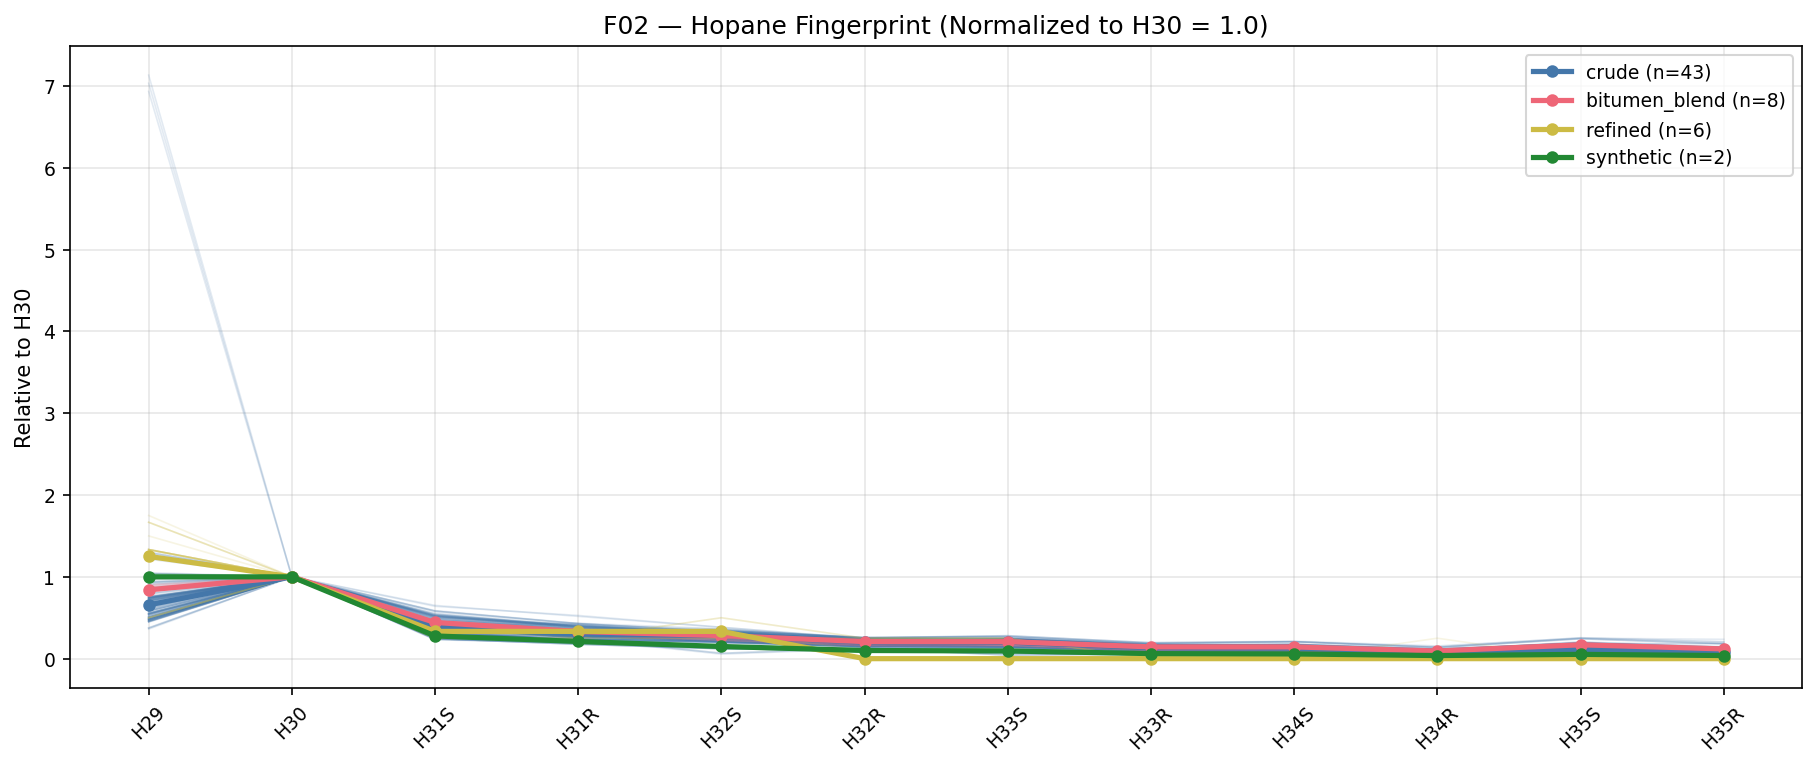

In [7]:
# F02 -- Hopane fingerprint overlay (all oils, colored by oil_type)
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for otype in OIL_TYPES_ML:
    sub = hop_wide[hop_wide['oil_type'] == otype]
    color = OILTYPE_COLORS.get(otype, 'grey')
    for _, row in sub.iterrows():
        vals = row[HOPANE_ORDER].values.astype(float)
        ax.plot(HOPANE_ORDER, vals, '-', color=color, alpha=0.15, linewidth=0.8)
    # Plot median line
    medians = sub[HOPANE_ORDER].median()
    ax.plot(HOPANE_ORDER, medians.values, 'o-', color=color, linewidth=2.5,
            markersize=5, label=f'{otype} (n={sub["oil_id"].nunique()})', zorder=10)

ax.set_ylabel('Relative to H30', fontsize=10)
ax.set_title('F02 — Hopane Fingerprint (Normalized to H30 = 1.0)', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
fig_path = FIG_DIR / 'F02_hopane_fingerprint_all_oils.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

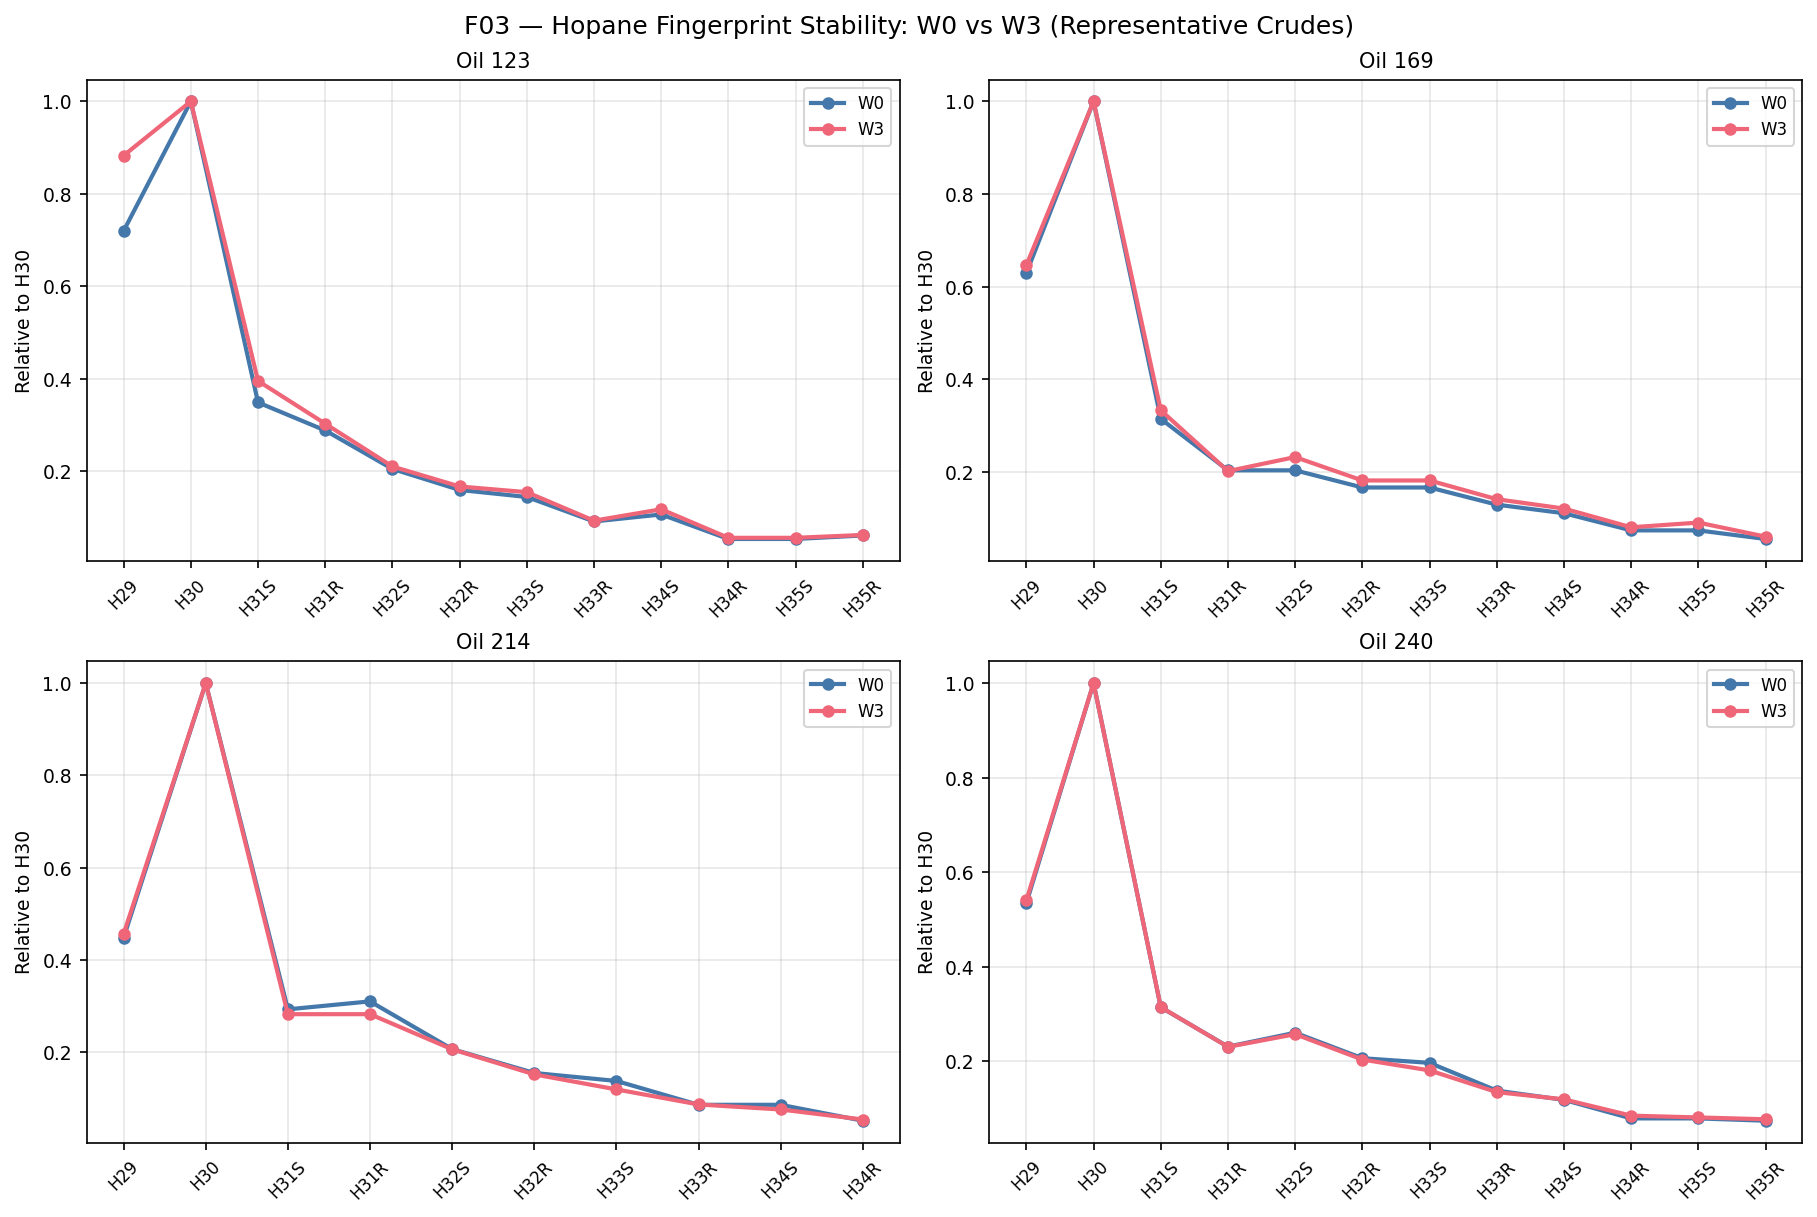

In [8]:
# F03 -- Hopane fingerprint W0 vs W3 for 4 representative crudes (stability close-up)
# Only select crudes that have BOTH W0 and W3 data
crude_hop = hop_wide[hop_wide['oil_type'] == 'crude']
ids_w0 = set(crude_hop[crude_hop['stage'] == 'W0']['oil_id'].unique())
ids_w3 = set(crude_hop[crude_hop['stage'] == 'W3']['oil_id'].unique())
valid_crude_ids = sorted(ids_w0 & ids_w3)

# Pick 4 evenly spaced from those with complete data
sel_ids = [valid_crude_ids[i] for i in np.linspace(0, len(valid_crude_ids)-1, 4, dtype=int)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, oid in zip(axes.flat, sel_ids):
    sub = hop_wide[(hop_wide['oil_id'] == oid) & (hop_wide['stage'].isin(['W0', 'W3']))]
    for _, row in sub.iterrows():
        vals = row[HOPANE_ORDER].values.astype(float)
        color = STAGE_COLORS.get(row['stage'], 'grey')
        ax.plot(HOPANE_ORDER, vals, 'o-', color=color, markersize=5,
                label=row['stage'], linewidth=2)
    ax.set_title(f'Oil {oid}', fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylabel('Relative to H30', fontsize=9)

fig.suptitle('F03 — Hopane Fingerprint Stability: W0 vs W3 (Representative Crudes)', fontsize=12)
fig_path = FIG_DIR / 'F03_hopane_fingerprint_representative_crudes.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## Part 3 — Sterane Ternary Diagram

In [9]:
# C05 -- Sterane ternary: C27 / C28 / C29 relative proportions
df_ster = df_bio[df_bio['bio_class'] == 'sterane'].copy()
ster_wide = df_ster.pivot_table(index=['oil_id', 'oil_type', 'stage'],
                                 columns='abbrev', values='intensity')
ster_wide = ster_wide.reset_index()

# Compute relative fractions
total = ster_wide['C27'] + ster_wide['C28'] + ster_wide['C29']
ster_wide['f_C27'] = ster_wide['C27'] / total.replace(0, np.nan)
ster_wide['f_C28'] = ster_wide['C28'] / total.replace(0, np.nan)
ster_wide['f_C29'] = ster_wide['C29'] / total.replace(0, np.nan)
ster_wide = ster_wide.dropna(subset=['f_C27', 'f_C28', 'f_C29'])

print(f'Sterane ternary data: {len(ster_wide)} oil x stage combos')
print('Median fractions (W0, crude):')
w0c = ster_wide[(ster_wide['stage'] == 'W0') & (ster_wide['oil_type'] == 'crude')]
print(f'  C27: {w0c["f_C27"].median():.3f}  C28: {w0c["f_C28"].median():.3f}  C29: {w0c["f_C29"].median():.3f}')

Sterane ternary data: 194 oil x stage combos
Median fractions (W0, crude):
  C27: 0.343  C28: 0.267  C29: 0.356


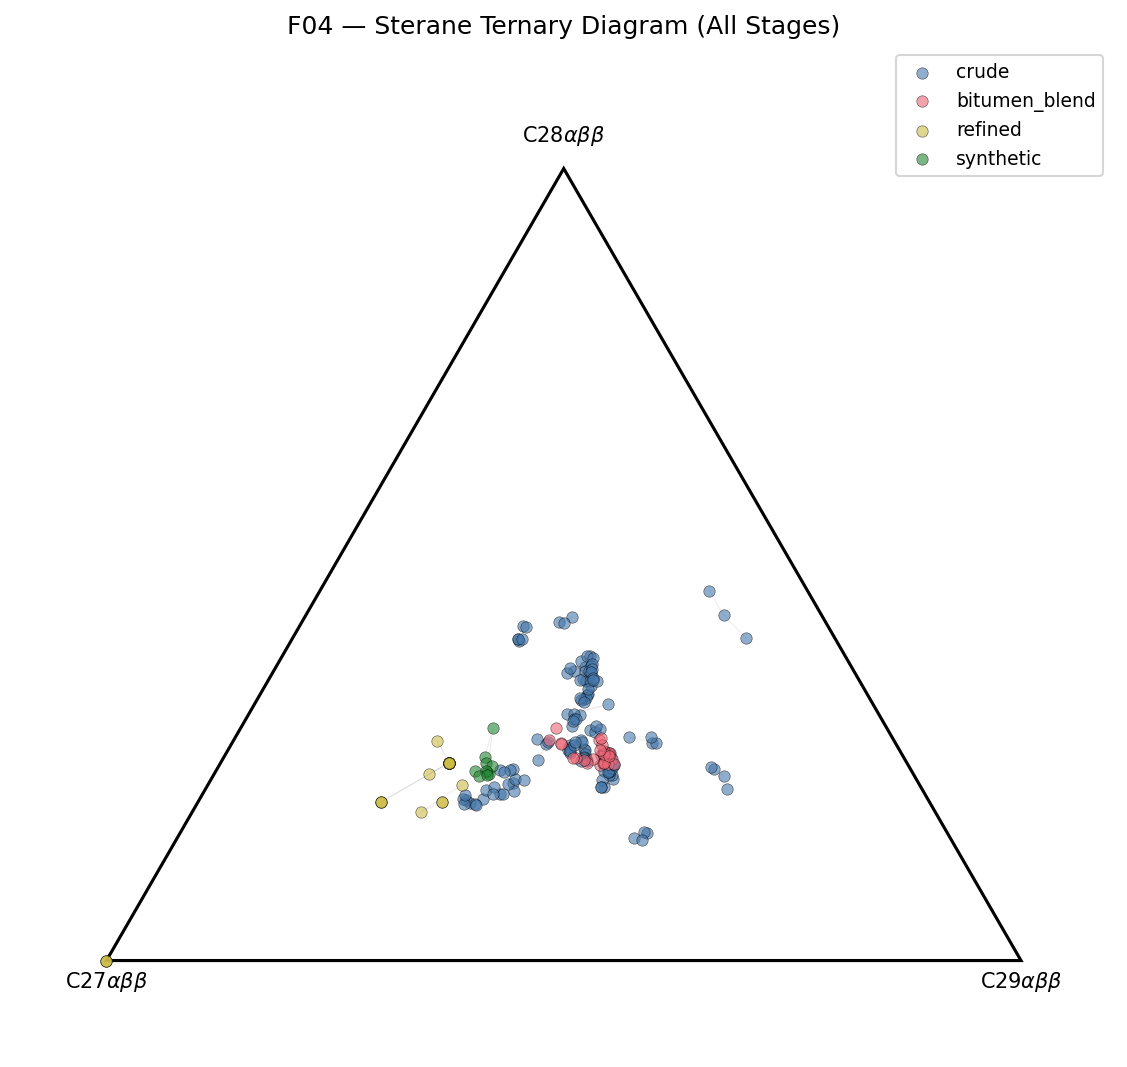

Grey lines connect the same oil across W0-W3 (tight = stable).


In [10]:
# F04 -- Sterane ternary diagram (plotted in Cartesian coordinates)
# Ternary: x = f_C29 + 0.5*f_C28, y = f_C28 * sqrt(3)/2
def ternary_coords(f27, f28, f29):
    x = f29 + 0.5 * f28
    y = f28 * np.sqrt(3) / 2
    return x, y

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

# Draw triangle
triangle = plt.Polygon([(0, 0), (1, 0), (0.5, np.sqrt(3)/2)],
                         fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(triangle)

# Plot points by oil_type
for otype in OIL_TYPES_ML:
    sub = ster_wide[ster_wide['oil_type'] == otype]
    if sub.empty:
        continue
    x, y = ternary_coords(sub['f_C27'].values, sub['f_C28'].values, sub['f_C29'].values)
    ax.scatter(x, y, c=OILTYPE_COLORS.get(otype, 'grey'), label=otype,
              s=30, alpha=0.6, edgecolors='k', linewidth=0.3, zorder=5)

# Connect same oil across stages (stability lines)
for oid in ster_wide['oil_id'].unique():
    sub = ster_wide[ster_wide['oil_id'] == oid].sort_values('stage')
    if len(sub) < 2:
        continue
    x, y = ternary_coords(sub['f_C27'].values, sub['f_C28'].values, sub['f_C29'].values)
    ax.plot(x, y, '-', color='grey', alpha=0.15, linewidth=0.5)

# Labels
ax.text(0, -0.03, r'C27$\alpha\beta\beta$', ha='center', fontsize=10)
ax.text(1, -0.03, r'C29$\alpha\beta\beta$', ha='center', fontsize=10)
ax.text(0.5, np.sqrt(3)/2 + 0.03, r'C28$\alpha\beta\beta$', ha='center', fontsize=10)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.0)
ax.set_aspect('equal')
ax.axis('off')
ax.legend(fontsize=9, loc='upper right')
ax.set_title('F04 — Sterane Ternary Diagram (All Stages)', fontsize=12)

fig_path = FIG_DIR / 'F04_sterane_ternary.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))
print('Grey lines connect the same oil across W0-W3 (tight = stable).')

## Part 4 — Terpane Ratios

In [11]:
# C06 -- Load diagnostic ratios for biomarker identity ratios
with get_conn() as conn:
    ph = ','.join('?' * len(IDENTITY_RATIOS))
    df_ratios = pd.read_sql(f"""
        SELECT r.oil_id, o.oil_name, o.oil_type, r.stage_code AS stage,
               r.ratio_name, r.value, r.is_valid
        FROM diagnostic_ratios r
        JOIN oils o ON r.oil_id = o.oil_id
        WHERE r.ratio_name IN ({ph})
          AND o.include_in_analysis = 1
          AND r.is_valid = 1
    """, conn, params=IDENTITY_RATIOS)

print(f'Loaded {len(df_ratios):,} biomarker ratio records')
print(df_ratios.groupby('ratio_name')['value'].agg(['count', 'median', 'std']).round(4).to_string())

Loaded 1,006 biomarker ratio records
            count  median     std
ratio_name                       
C23T_C24T     210  1.6325  0.5328
H29_H30       208  0.7331  0.7939
H31S_H31R     196  1.3429  0.1486
H32S_H32R     189  1.3721  0.2169
Ts_Tm         203  0.7500  0.3460


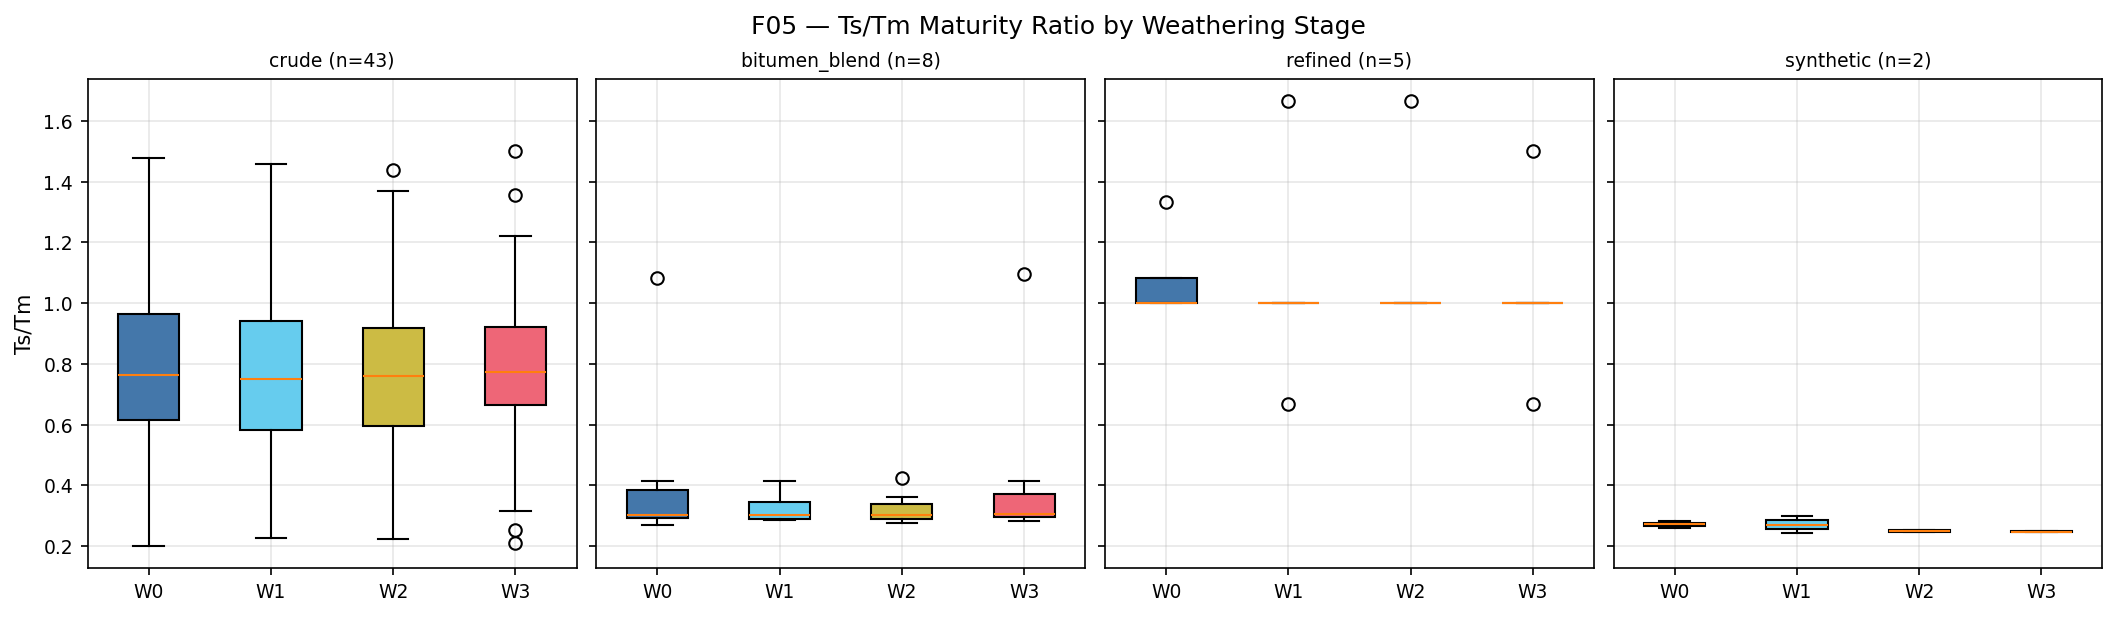

In [12]:
# F05 -- Ts/Tm by stage, faceted by oil_type
df_tstm = df_ratios[df_ratios['ratio_name'] == 'Ts_Tm']

fig, axes = plt.subplots(1, len(OIL_TYPES_ML), figsize=(14, 4), constrained_layout=True,
                          sharey=True)
for ax, otype in zip(axes, OIL_TYPES_ML):
    sub = df_tstm[df_tstm['oil_type'] == otype]
    data = [sub[sub['stage'] == s]['value'].dropna().values for s in STAGE_ORDER]
    data = [d for d in data if len(d) > 0]
    if not data:
        ax.set_title(f'{otype}\n(no data)', fontsize=9)
        continue
    bp = ax.boxplot(data, tick_labels=STAGE_ORDER[:len(data)], patch_artist=True, widths=0.5)
    for patch, stage in zip(bp['boxes'], STAGE_ORDER):
        patch.set_facecolor(STAGE_COLORS.get(stage, '#ccc'))
    ax.set_title(f'{otype} (n={sub["oil_id"].nunique()})', fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Ts/Tm', fontsize=10)
fig.suptitle('F05 — Ts/Tm Maturity Ratio by Weathering Stage', fontsize=12)
fig_path = FIG_DIR / 'F05_Ts_Tm_by_stage.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

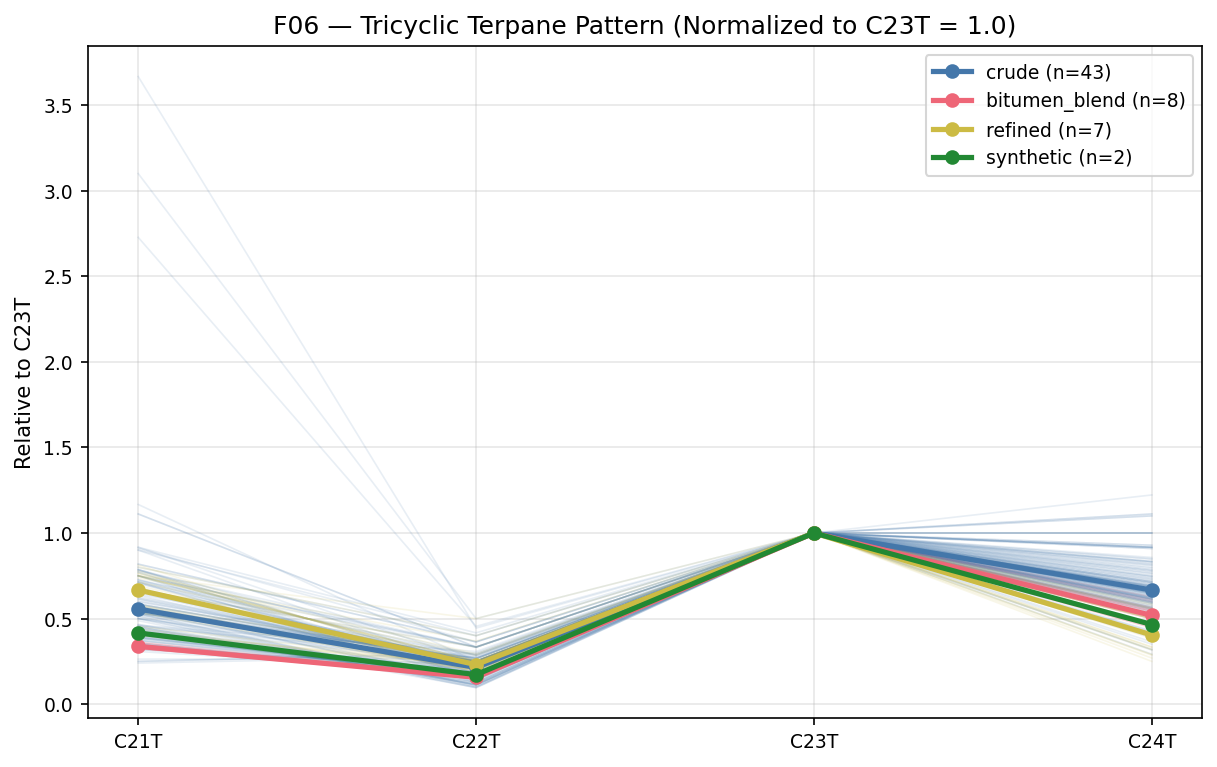

In [13]:
# F06 -- Tricyclic terpane pattern (C21T, C22T, C23T, C24T normalized to C23T)
TERPANE_ORDER = ['C21T', 'C22T', 'C23T', 'C24T']
df_terp = df_bio[df_bio['abbrev'].isin(TERPANE_ORDER)].copy()
terp_wide = df_terp.pivot_table(index=['oil_id', 'oil_type', 'stage'],
                                  columns='abbrev', values='intensity')
# Normalize to C23T
for col in TERPANE_ORDER:
    if col != 'C23T':
        terp_wide[col] = terp_wide[col] / terp_wide['C23T'].replace(0, np.nan)
terp_wide['C23T'] = 1.0
terp_wide = terp_wide.reindex(columns=TERPANE_ORDER).reset_index()

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
for otype in OIL_TYPES_ML:
    sub = terp_wide[terp_wide['oil_type'] == otype]
    color = OILTYPE_COLORS.get(otype, 'grey')
    for _, row in sub.iterrows():
        vals = row[TERPANE_ORDER].values.astype(float)
        ax.plot(TERPANE_ORDER, vals, '-', color=color, alpha=0.12, linewidth=0.8)
    medians = sub[TERPANE_ORDER].median()
    ax.plot(TERPANE_ORDER, medians.values, 'o-', color=color, linewidth=2.5,
            markersize=6, label=f'{otype} (n={sub["oil_id"].nunique()})', zorder=10)

ax.set_ylabel('Relative to C23T', fontsize=10)
ax.set_title('F06 — Tricyclic Terpane Pattern (Normalized to C23T = 1.0)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig_path = FIG_DIR / 'F06_tricyclic_terpane_pattern.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## Part 5 — Stability Assessment

In [14]:
# C07 -- Wilcoxon signed-rank: all biomarker identity ratios W0 vs W3
alpha_bonf = 0.05 / len(IDENTITY_RATIOS)
print(f'=== Wilcoxon signed-rank: biomarker identity ratios ===')
print(f'Bonferroni correction: alpha/{len(IDENTITY_RATIOS)} = {alpha_bonf:.4f}')
print()

wilcox_results = []
for rname in IDENTITY_RATIOS:
    sub = df_ratios[df_ratios['ratio_name'] == rname]
    w0 = sub[sub['stage'] == 'W0'].set_index('oil_id')['value']
    w3 = sub[sub['stage'] == 'W3'].set_index('oil_id')['value']
    common = w0.index.intersection(w3.index)
    n = len(common)
    if n < 5:
        print(f'{rname}: insufficient pairs (n={n})')
        wilcox_results.append({'ratio': rname, 'n': n, 'stat': np.nan,
                               'p': np.nan, 'note': 'insufficient'})
        continue
    arr0 = w0[common].values
    arr3 = w3[common].values
    diffs = arr3 - arr0
    median_delta = np.median(diffs)
    if np.all(diffs == 0):
        print(f'{rname}: PERFECTLY STABLE (all diffs = 0, n={n})')
        wilcox_results.append({'ratio': rname, 'n': n, 'stat': 0.0,
                               'p': 1.0, 'median_delta': 0.0, 'note': 'perfectly_stable'})
        continue
    nonzero = diffs[diffs != 0]
    stat_w, p_w = wilcoxon(nonzero)
    sig = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*' if p_w < alpha_bonf else 'ns'
    result = 'SIGNIFICANT' if p_w < alpha_bonf else 'STABLE'
    print(f'{rname}: p={p_w:.4f} {sig} | median delta={median_delta:.6f} | n={n} -> {result}')
    wilcox_results.append({'ratio': rname, 'n': n, 'stat': stat_w,
                           'p': p_w, 'median_delta': median_delta, 'note': result})

df_wilcox = pd.DataFrame(wilcox_results)
n_sig = (df_wilcox['p'] < alpha_bonf).sum()
print(f'\nSignificant after Bonferroni: {n_sig}/{len(IDENTITY_RATIOS)}')

=== Wilcoxon signed-rank: biomarker identity ratios ===
Bonferroni correction: alpha/5 = 0.0100

Ts_Tm: p=0.8711 ns | median delta=0.003022 | n=48 -> STABLE
H29_H30: p=0.8456 ns | median delta=0.000000 | n=50 -> STABLE
H31S_H31R: p=0.1172 ns | median delta=0.004965 | n=47 -> STABLE
H32S_H32R: p=0.6873 ns | median delta=0.004032 | n=45 -> STABLE
C23T_C24T: p=0.4631 ns | median delta=0.004525 | n=51 -> STABLE

Significant after Bonferroni: 0/5


In [15]:
# C08 -- Biomarker compound change W0 -> W3 (crude only)
# Note: positive values = apparent enrichment from matrix concentration (not compound addition)
df_crude = df_bio[(df_bio['oil_type'] == 'crude') & (~df_bio['is_missing'])].copy()

change_records = []
for abbrev, comp_name in ALL_BIOMARKERS.items():
    sub = df_crude[df_crude['abbrev'] == abbrev]
    w0 = sub[sub['stage'] == 'W0'].set_index('oil_id')['intensity']
    w3 = sub[sub['stage'] == 'W3'].set_index('oil_id')['intensity']
    common = w0.index.intersection(w3.index)
    if len(common) < 3:
        continue
    change_pct = ((w3[common] - w0[common]) / w0[common].replace(0, np.nan) * 100)
    change_records.append({
        'abbrev': abbrev,
        'bio_class': 'hopane' if comp_name in hopane_names else 'terpane' if comp_name in terpane_names else 'sterane',
        'median_change_pct': change_pct.median(),
        'q25': change_pct.quantile(0.25),
        'q75': change_pct.quantile(0.75),
        'n': len(common),
    })

df_change = pd.DataFrame(change_records)
print('Biomarker change W0->W3 (crude oils, %):')
print(df_change[['abbrev', 'bio_class', 'median_change_pct', 'n']].to_string(index=False))
print()
print('Note: positive values = apparent enrichment from matrix concentration effect')


Biomarker change W0->W3 (crude oils, %):
abbrev bio_class  median_change_pct  n
   H29    hopane          28.964613 34
   H30    hopane          27.826010 34
  H31S    hopane          29.793907 34
  H31R    hopane          30.901857 34
  H32S    hopane          30.372807 34
  H32R    hopane          31.006865 34
  H33S    hopane          34.313725 34
  H33R    hopane          34.848485 34
  H34S    hopane          33.333333 34
  H34R    hopane          33.333333 34
  H35S    hopane          29.411765 27
  H35R    hopane          33.333333 27
    Tm   terpane          30.842391 34
    Ts   terpane          28.571429 34
  C21T   terpane          28.571429 27
  C22T   terpane          33.333333 27
  C23T   terpane          33.333333 34
  C24T   terpane          32.051282 34
   C27   sterane          29.985024 34
   C28   sterane          28.915663 27
   C29   sterane          29.792089 34

Note: positive values = apparent enrichment from matrix concentration effect


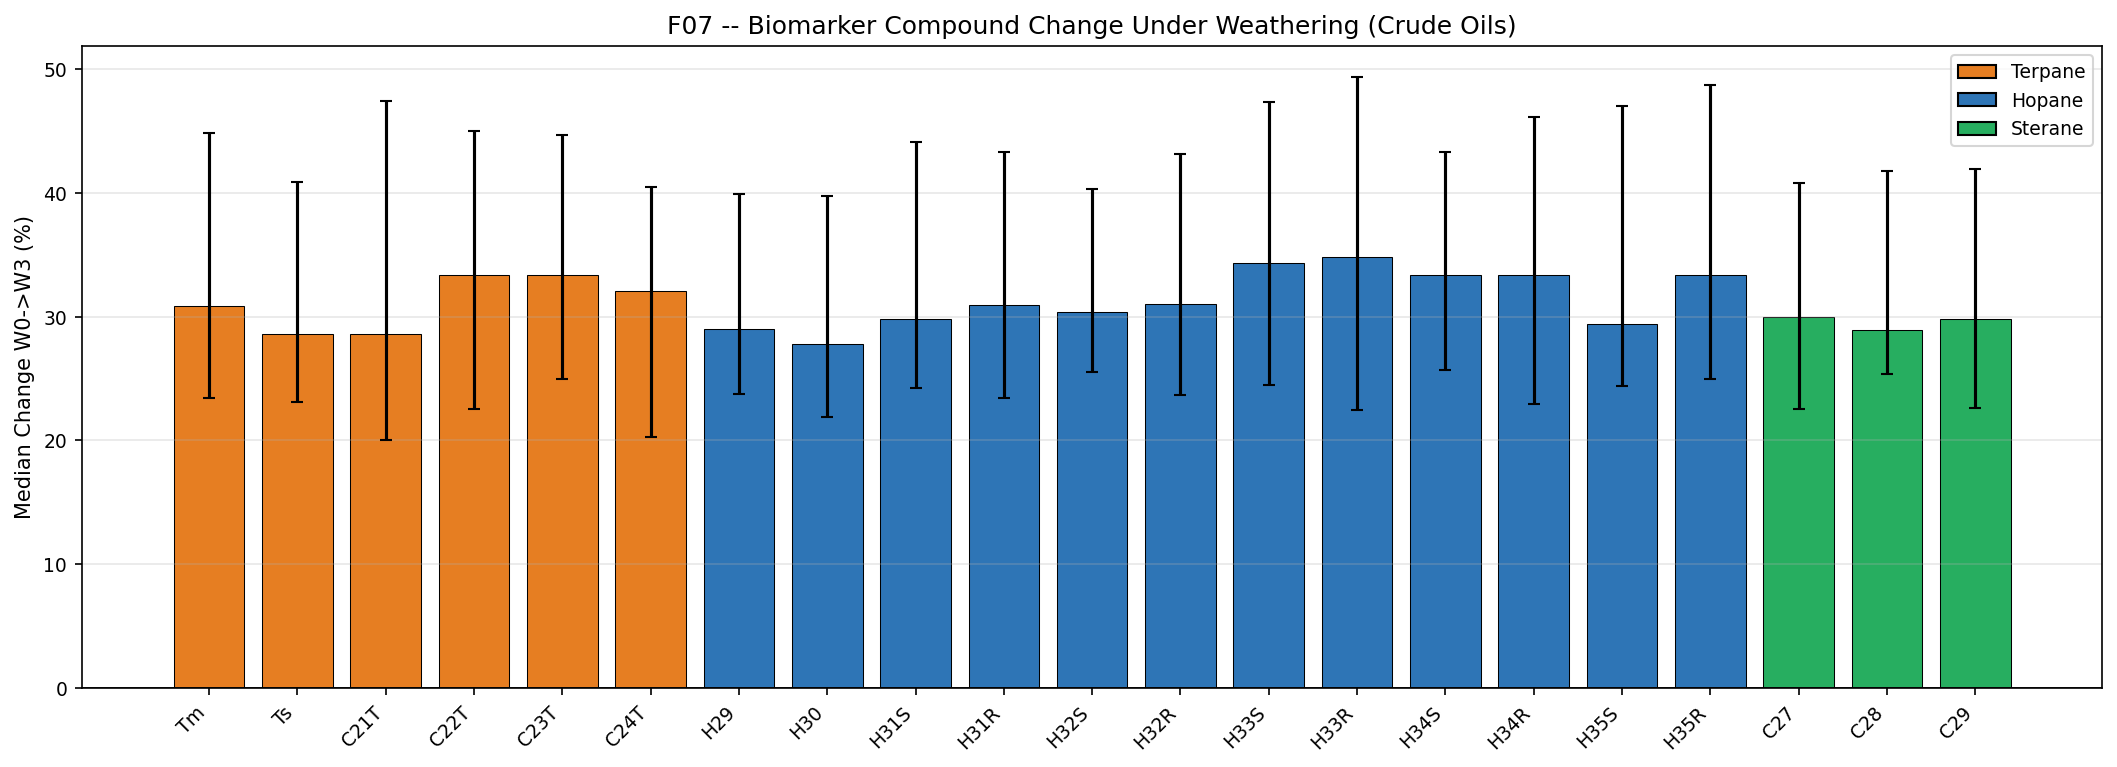

Note: positive change = matrix concentration effect, not compound addition


In [16]:
# F07 -- Change % bar chart for all 21 biomarker compounds
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

# Reorder by class
order_map = {a: i for i, a in enumerate(
    list(TERPANES.keys()) + list(HOPANES.keys()) + list(STERANES.keys()))}
df_change_sorted = df_change.sort_values('abbrev', key=lambda s: s.map(order_map))

colors = {'hopane': '#2E75B6', 'terpane': '#E67E22', 'sterane': '#27AE60'}
bar_colors = [colors.get(c, 'grey') for c in df_change_sorted['bio_class']]

ax.bar(range(len(df_change_sorted)), df_change_sorted['median_change_pct'],
       yerr=[df_change_sorted['median_change_pct'] - df_change_sorted['q25'],
             df_change_sorted['q75'] - df_change_sorted['median_change_pct']],
       color=bar_colors, edgecolor='k', linewidth=0.5, capsize=3)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(df_change_sorted)))
ax.set_xticklabels(df_change_sorted['abbrev'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Median Change W0->W3 (%)', fontsize=10)
ax.set_title('F07 -- Biomarker Compound Change Under Weathering (Crude Oils)', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[c], edgecolor='k', label=c.capitalize())
                   for c in ['terpane', 'hopane', 'sterane']]
ax.legend(handles=legend_elements, fontsize=9)
ax.grid(alpha=0.3, axis='y')

fig_path = FIG_DIR / 'F07_biomarker_change_boxplot.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))
print('Note: positive change = matrix concentration effect, not compound addition')


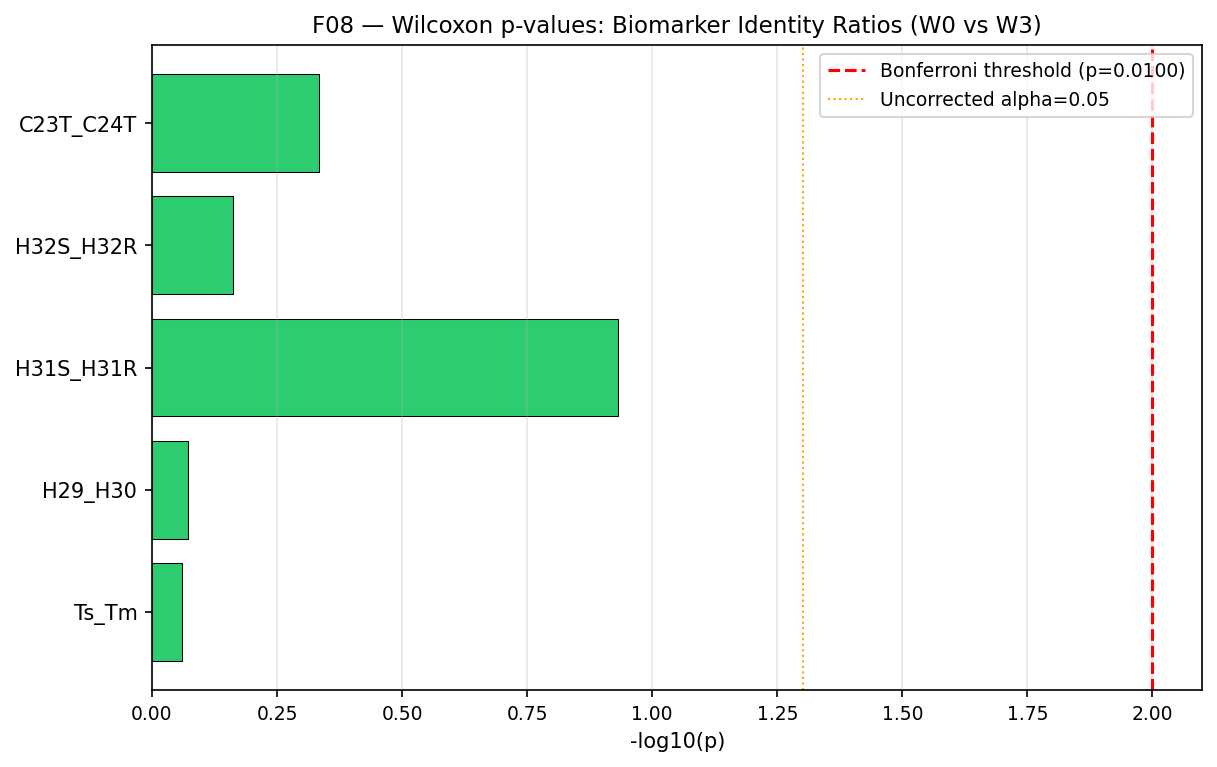

In [17]:
# F08 -- Wilcoxon p-values bar chart for biomarker identity ratios
df_wplot = df_wilcox.dropna(subset=['p']).copy()
df_wplot['neg_log_p'] = -np.log10(df_wplot['p'].clip(lower=1e-20))

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
bar_colors_w = ['#E74C3C' if p < alpha_bonf else '#2ECC71' for p in df_wplot['p']]
ax.barh(range(len(df_wplot)), df_wplot['neg_log_p'], color=bar_colors_w,
        edgecolor='k', linewidth=0.5)
ax.axvline(-np.log10(alpha_bonf), color='red', linestyle='--', linewidth=1.5,
           label=f'Bonferroni threshold (p={alpha_bonf:.4f})')
ax.axvline(-np.log10(0.05), color='orange', linestyle=':', linewidth=1,
           label='Uncorrected alpha=0.05')
ax.set_yticks(range(len(df_wplot)))
ax.set_yticklabels(df_wplot['ratio'], fontsize=10)
ax.set_xlabel('-log10(p)', fontsize=10)
ax.set_title('F08 — Wilcoxon p-values: Biomarker Identity Ratios (W0 vs W3)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='x')

fig_path = FIG_DIR / 'F08_wilcoxon_pvalues_biomarker_ratios.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## Part 6 — Concentration Effect

In [18]:
# C09 -- Concentration effect: H30 increases with weathering (matrix effect)
h30 = df_bio[(df_bio['abbrev'] == 'H30') & (df_bio['oil_type'] == 'crude') &
             (~df_bio['is_missing'])].copy()
h30_w0 = h30[h30['stage'] == 'W0'].set_index('oil_id')['intensity']
h30_w3 = h30[h30['stage'] == 'W3'].set_index('oil_id')['intensity']
common_h30 = h30_w0.index.intersection(h30_w3.index)

conc_ratio = h30_w3[common_h30] / h30_w0[common_h30].replace(0, np.nan)

# Load mass loss
with get_conn() as conn:
    df_ml = pd.read_sql("""
        SELECT oil_id, stage_code AS stage, value AS mass_loss_pct
        FROM sample_properties
        WHERE property_name = 'evaporative_mass_loss'
          AND stage_code = 'W3'
    """, conn)
mass_loss = df_ml.set_index('oil_id')['mass_loss_pct']

print(f'H30 concentration ratio (W3/W0): median = {conc_ratio.median():.3f}')
print(f'Expected from mass loss: 1/(1-median_loss) = {1/(1 - mass_loss.median()/100):.3f}')

H30 concentration ratio (W3/W0): median = 1.278
Expected from mass loss: 1/(1-median_loss) = 1.307


Concentration effect: 35 oils with both H30 ratio and mass loss


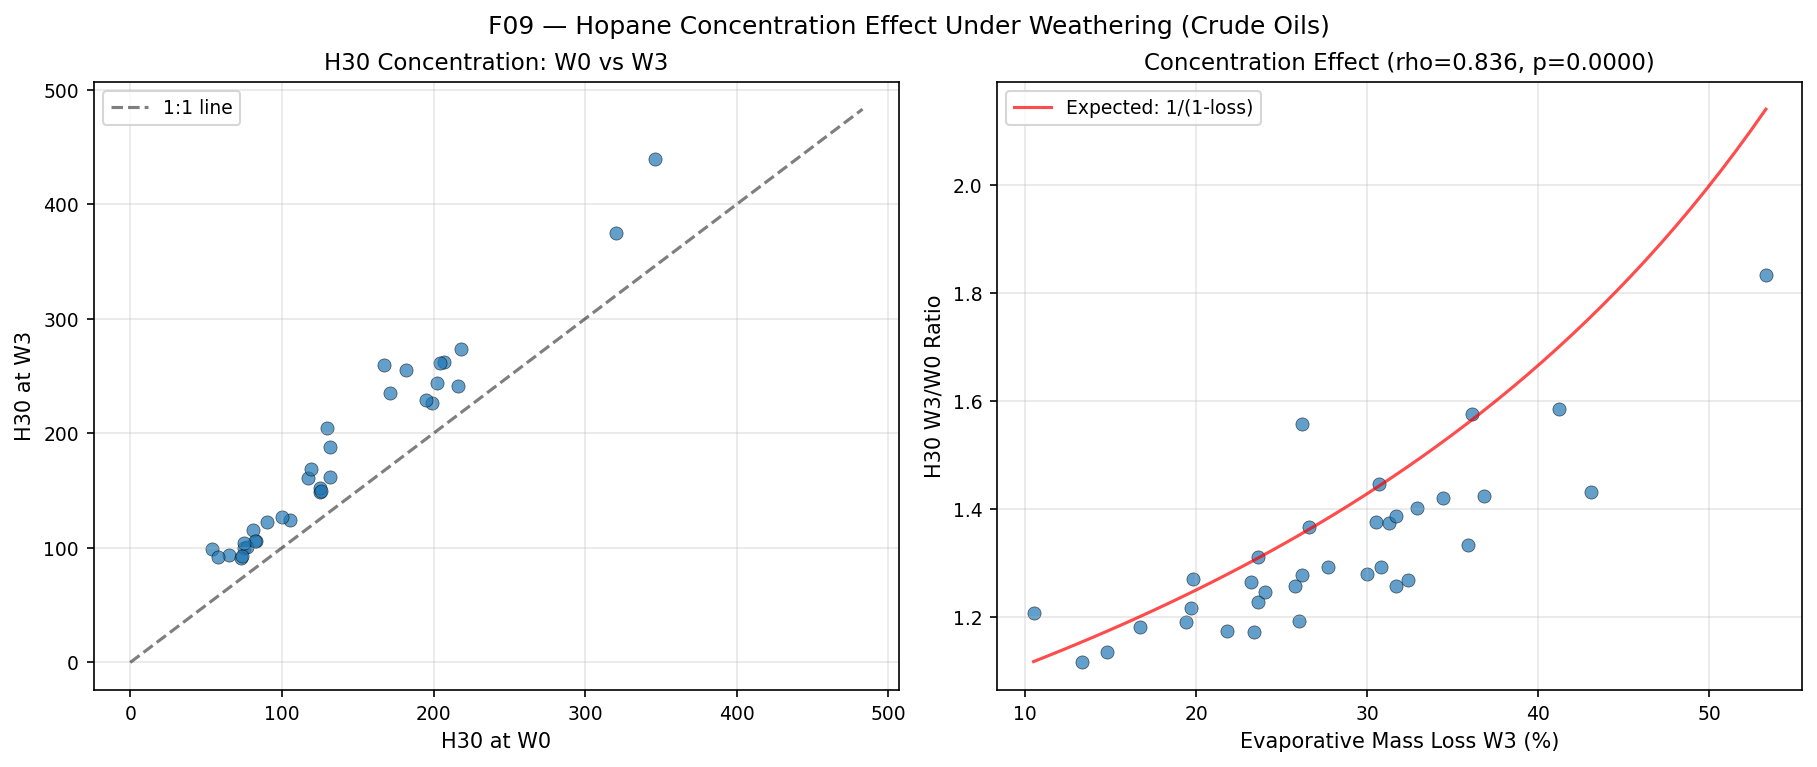

In [19]:
# F09 -- H30 concentration W0 vs W3 scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Panel 1: W0 vs W3 with 1:1 line
vals_w0 = h30_w0[common_h30].values
vals_w3 = h30_w3[common_h30].values
ax1.scatter(vals_w0, vals_w3, s=40, alpha=0.7, edgecolors='k', linewidth=0.3)
lims = [0, max(vals_w0.max(), vals_w3.max()) * 1.1]
ax1.plot(lims, lims, 'k--', alpha=0.5, label='1:1 line')
ax1.set_xlabel('H30 at W0', fontsize=10)
ax1.set_ylabel('H30 at W3', fontsize=10)
ax1.set_title('H30 Concentration: W0 vs W3', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Panel 2: concentration ratio vs mass loss (merge approach)
df_cr = conc_ratio.reset_index()
df_cr.columns = ['oil_id', 'conc_ratio']
df_cr['oil_id'] = df_cr['oil_id'].astype(int)

df_ml_plot = df_ml[['oil_id', 'mass_loss_pct']].copy()
df_ml_plot['oil_id'] = df_ml_plot['oil_id'].astype(int)

df_merged = df_cr.merge(df_ml_plot, on='oil_id', how='inner').dropna()
print(f'Concentration effect: {len(df_merged)} oils with both H30 ratio and mass loss')

if len(df_merged) >= 5:
    ml_vals = df_merged['mass_loss_pct'].values
    cr_vals = df_merged['conc_ratio'].values
    ax2.scatter(ml_vals, cr_vals, s=40, alpha=0.7, edgecolors='k', linewidth=0.3)
    rho, p = spearmanr(ml_vals, cr_vals)
    # Expected curve: 1/(1-loss/100)
    x_line = np.linspace(ml_vals.min(), ml_vals.max(), 50)
    ax2.plot(x_line, 1 / (1 - x_line / 100), 'r-', alpha=0.7,
             label='Expected: 1/(1-loss)')
    ax2.set_xlabel('Evaporative Mass Loss W3 (%)', fontsize=10)
    ax2.set_ylabel('H30 W3/W0 Ratio', fontsize=10)
    ax2.set_title(f'Concentration Effect (rho={rho:.3f}, p={p:.4f})', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

fig.suptitle('F09 — Hopane Concentration Effect Under Weathering (Crude Oils)', fontsize=12)
fig_path = FIG_DIR / 'F09_H30_concentration_W0_vs_W3.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## Part 7 — Oil-Type Discrimination

In [20]:
# C10 -- Kruskal-Wallis: which biomarker ratios discriminate oil types? (W0 only)
# Also include extended ratios not in IDENTITY_RATIOS
ALL_BIO_RATIOS = IDENTITY_RATIOS  # Only use ratios that exist in diagnostic_ratios

w0_ratios = df_ratios[df_ratios['stage'] == 'W0']

kw_results = []
for rname in ALL_BIO_RATIOS:
    sub = w0_ratios[w0_ratios['ratio_name'] == rname]
    groups = [sub[sub['oil_type'] == ot]['value'].dropna().values
              for ot in OIL_TYPES_ML]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        continue
    stat_kw, p_kw = kruskal(*groups)
    kw_results.append({'ratio': rname, 'kw_stat': stat_kw, 'p': p_kw,
                       'n_types': len(groups)})

df_kw = pd.DataFrame(kw_results).sort_values('p')
print('Kruskal-Wallis: biomarker ratios across oil types (W0):')
for _, row in df_kw.iterrows():
    sig = '***' if row['p'] < 0.001 else '**' if row['p'] < 0.01 else '*' if row['p'] < 0.05 else 'ns'
    print(f"  {row['ratio']:15s} KW={row['kw_stat']:8.2f}  p={row['p']:.2e}  {sig}")

Kruskal-Wallis: biomarker ratios across oil types (W0):
  C23T_C24T       KW=   23.31  p=8.69e-06  ***
  H29_H30         KW=   12.79  p=1.67e-03  **
  Ts_Tm           KW=   12.61  p=1.83e-03  **
  H31S_H31R       KW=    7.18  p=2.76e-02  *
  H32S_H32R       KW=    0.00  p=9.79e-01  ns


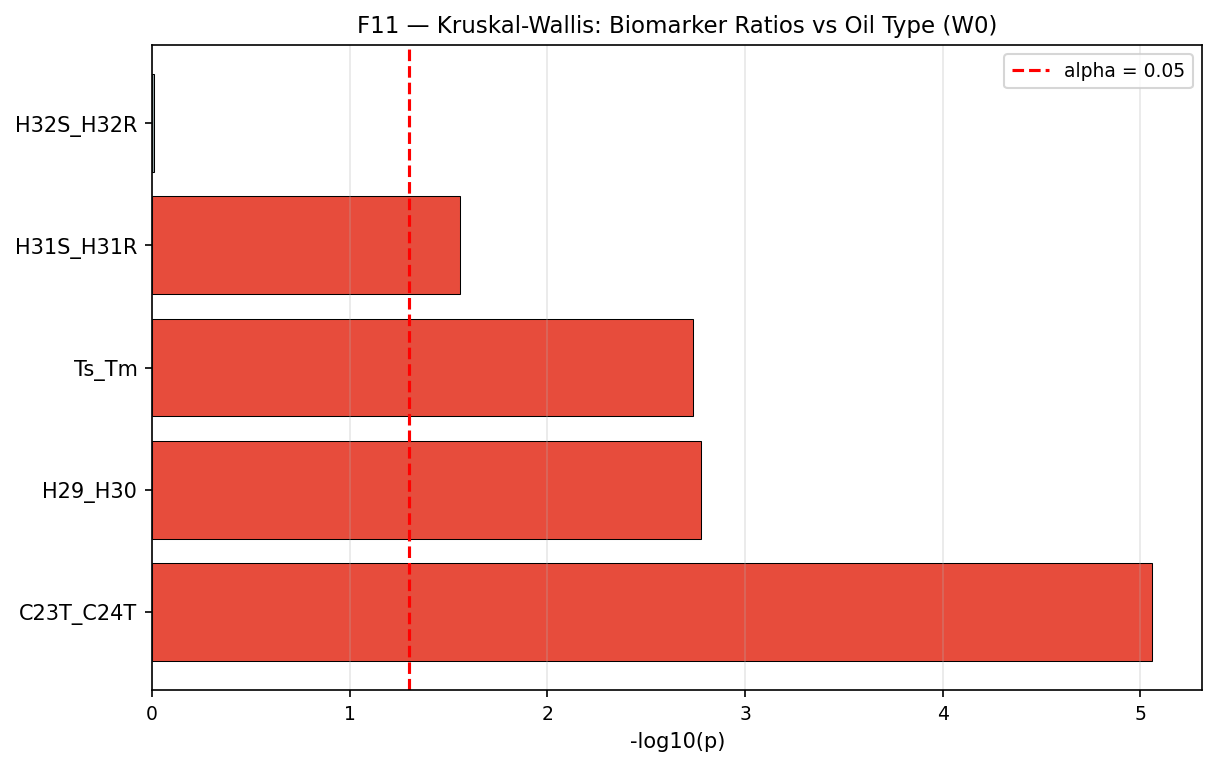

In [21]:
# F11 -- KW p-values bar chart
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
df_kw_plot = df_kw.copy()
df_kw_plot['neg_log_p'] = -np.log10(df_kw_plot['p'].clip(lower=1e-20))
bar_colors_kw = ['#E74C3C' if p < 0.05 else '#95A5A6' for p in df_kw_plot['p']]

ax.barh(range(len(df_kw_plot)), df_kw_plot['neg_log_p'], color=bar_colors_kw,
        edgecolor='k', linewidth=0.5)
ax.axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=1.5,
           label='alpha = 0.05')
ax.set_yticks(range(len(df_kw_plot)))
ax.set_yticklabels(df_kw_plot['ratio'], fontsize=10)
ax.set_xlabel('-log10(p)', fontsize=10)
ax.set_title('F11 — Kruskal-Wallis: Biomarker Ratios vs Oil Type (W0)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='x')

fig_path = FIG_DIR / 'F11_KW_pvalues_oil_type_discrimination.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

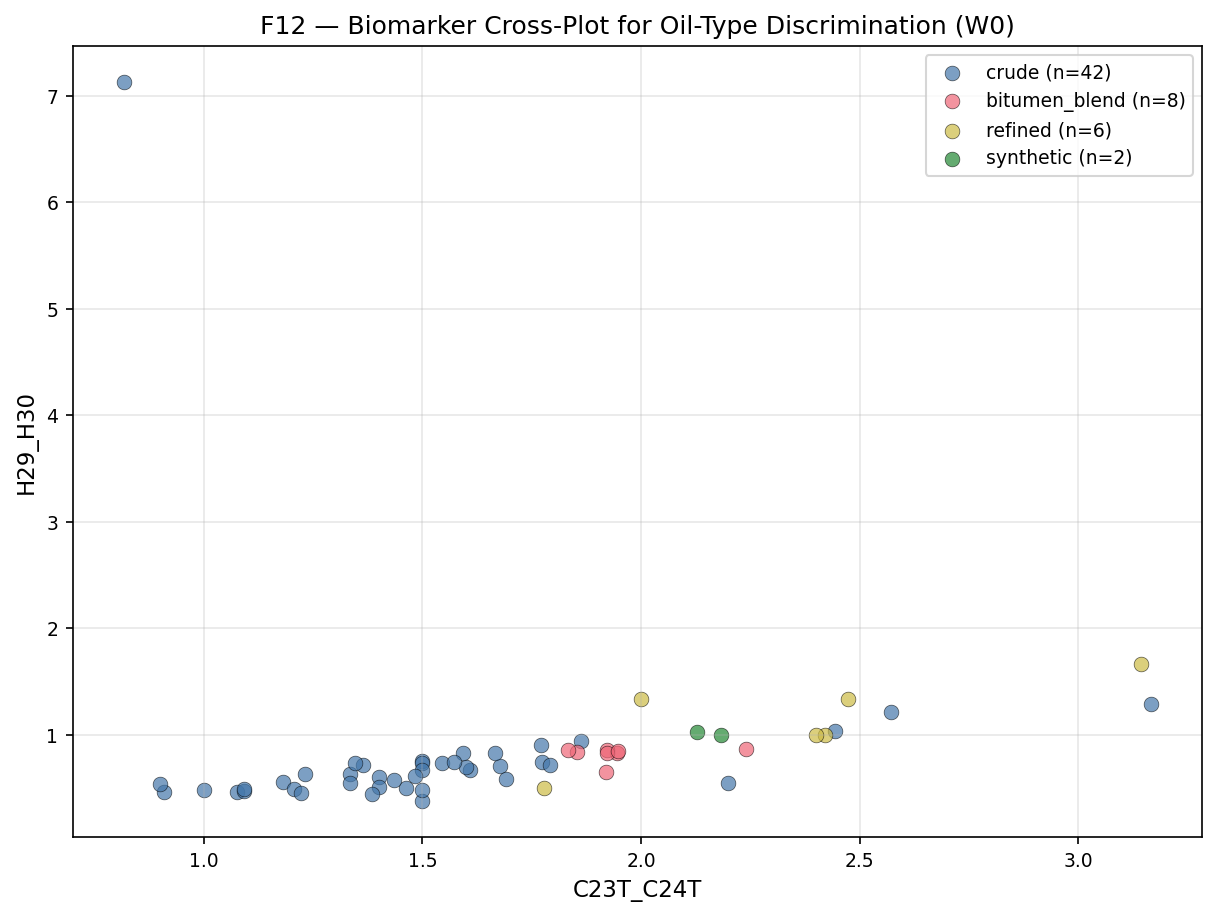

In [22]:
# F12 -- Best cross-plot for oil-type discrimination (top 2 KW ratios)
if len(df_kw) >= 2:
    r1 = df_kw.iloc[0]['ratio']
    r2 = df_kw.iloc[1]['ratio']
    
    w0_wide = w0_ratios.pivot_table(index=['oil_id', 'oil_type'],
                                     columns='ratio_name', values='value')
    w0_wide = w0_wide.reset_index().dropna(subset=[r1, r2])
    
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    for otype in OIL_TYPES_ML:
        sub = w0_wide[w0_wide['oil_type'] == otype]
        if sub.empty:
            continue
        ax.scatter(sub[r1], sub[r2], c=OILTYPE_COLORS.get(otype, 'grey'),
                  label=f'{otype} (n={len(sub)})', s=50, alpha=0.7,
                  edgecolors='k', linewidth=0.3)
    ax.set_xlabel(r1, fontsize=11)
    ax.set_ylabel(r2, fontsize=11)
    ax.set_title(f'F12 — Biomarker Cross-Plot for Oil-Type Discrimination (W0)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    fig_path = FIG_DIR / 'F12_best_crossplot_oil_type.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close('all')
    display(Image(filename=str(fig_path)))
else:
    print('Not enough KW-significant ratios for cross-plot.')

## Part 8 — Summary and Integration

In [23]:
# C11 -- Persist H30 concentration ratio per oil to molecular_fingerprint_stats
persist_records = []

for oid in common_h30:
    cr_val = float(conc_ratio.get(oid, np.nan))
    if not np.isnan(cr_val):
        persist_records.append((int(oid), 'W3', 'h30_concentration_ratio', cr_val))

with get_conn() as conn:
    conn.executemany(
        'INSERT OR REPLACE INTO molecular_fingerprint_stats '
        '(oil_id, stage_code, stat_name, stat_value) VALUES (?, ?, ?, ?)',
        persist_records)

print(f'Persisted {len(persist_records)} H30 concentration ratio records.')

# Biomarker change summary (not per-oil) -- print only
print('\nBiomarker change summary (crude oils, median %):')
for _, row in df_change.iterrows():
    print(f'  {row["abbrev"]:6s} {row["median_change_pct"]:+.1f}%')


Persisted 34 H30 concentration ratio records.

Biomarker change summary (crude oils, median %):
  H29    +29.0%
  H30    +27.8%
  H31S   +29.8%
  H31R   +30.9%
  H32S   +30.4%
  H32R   +31.0%
  H33S   +34.3%
  H33R   +34.8%
  H34S   +33.3%
  H34R   +33.3%
  H35S   +29.4%
  H35R   +33.3%
  Tm     +30.8%
  Ts     +28.6%
  C21T   +28.6%
  C22T   +33.3%
  C23T   +33.3%
  C24T   +32.1%
  C27    +30.0%
  C28    +28.9%
  C29    +29.8%


### Integration: Thermodynamic Hierarchy

This notebook completes the third tier of the geochemical hierarchy:

| Domain | Notebook | Weathering signal | Key finding |
|---|---|---|---|
| n-Alkanes | NB03c | Strong depletion (C9-C15 > -90%) | Thermodynamic: Spearman rho=0.987 with boiling point |
| PAHs | NB03c2 | Naphthalenes deplete (~-63%), higher PAHs stable | Only lowest-BP series affected at 80C |
| **Biomarkers** | **NB03c3** | **No depletion** | **Pure identity markers: 0/5 significant after Bonferroni** |

Sterane identity ratios C27/C29 and C28/C29 are not computed in NB02 (sterane
compounds exist in measurements but the ratios were classified as `not_available`);
their stability is inferred from the sterane ternary diagram (F04).

This confirms the ECCC ESTS protocol operates within a regime where:
1. Volatile compounds (BP <300C) deplete proportionally to boiling point
2. Semi-volatile PAHs (BP 300-400C) are mostly stable except naphthalenes
3. Refractory biomarkers (BP >400C) are completely unaffected

The SHAP model (NB06) correctly uses biomarker ratios as identity markers,
not weathering indicators -- this EDA provides the empirical foundation.


In [24]:
# C12 -- Summary print block
print('NB03c3 SUMMARY')
print('==============')
# F-NB03c3-M1 (28/abr/2026): df_depl was never defined; fall back to df_bio compound count
n_valid_compounds = df_bio['compound_name'].nunique()
print(f'Biomarker compounds with valid data: {n_valid_compounds}/{len(ALL_BIOMARKERS)}')
h30_cr = conc_ratio.median()
print(f'H30 concentration ratio (W3/W0): median = {h30_cr:.3f}')
if mass_loss.median() > 0:
    expected_cr = 1 / (1 - mass_loss.median() / 100)
    print(f'Expected from mass loss: 1/(1-{mass_loss.median():.1f}%) = {expected_cr:.3f}')
n_sig = (df_wilcox['p'] < alpha_bonf).sum()
print(f'Identity ratios significant after Bonferroni: {n_sig}/{len(IDENTITY_RATIOS)} (expected: 0)')

if len(df_kw) > 0:
    best = df_kw.iloc[0]
    print(f'Best oil-type discriminator: {best["ratio"]} (KW p = {best["p"]:.2e})')

print(f'\nFigures saved to: {FIG_DIR}')
print('Biomarkers confirmed as PURE IDENTITY MARKERS under ECCC ESTS protocol.')

NB03c3 SUMMARY
Biomarker compounds with valid data: 21/21
H30 concentration ratio (W3/W0): median = 1.278
Expected from mass loss: 1/(1-23.5%) = 1.307
Identity ratios significant after Bonferroni: 0/5 (expected: 0)
Best oil-type discriminator: C23T_C24T (KW p = 8.69e-06)

Figures saved to: C:\Users\leogr\Documents\Data Science\TCC\figures\nb03c3
Biomarkers confirmed as PURE IDENTITY MARKERS under ECCC ESTS protocol.


## Part 9 -- Extended Analyses


In [25]:
# B1 -- Maturity parameters: 22S/(22S+22R) for homohopanes
maturity_pairs = [
    ('H31S', 'H31R', 'H31'),
    ('H32S', 'H32R', 'H32'),
]

mat_results = []
for s_abbrev, r_abbrev, label in maturity_pairs:
    s_vals = df_bio[(df_bio['abbrev'] == s_abbrev) & (df_bio['stage'] == 'W0')
                    & (~df_bio['is_missing'])].set_index('oil_id')['intensity']
    r_vals = df_bio[(df_bio['abbrev'] == r_abbrev) & (df_bio['stage'] == 'W0')
                    & (~df_bio['is_missing'])].set_index('oil_id')['intensity']
    common = s_vals.index.intersection(r_vals.index)
    ratio_22S = s_vals[common] / (s_vals[common] + r_vals[common])
    mat_results.append({
        'parameter': f'{label} 22S/(22S+22R)',
        'mean': ratio_22S.mean(), 'std': ratio_22S.std(),
        'min': ratio_22S.min(), 'max': ratio_22S.max(),
        'n': len(common),
        'n_equilibrium': ((ratio_22S >= 0.55) & (ratio_22S <= 0.65)).sum(),
    })

df_mat = pd.DataFrame(mat_results)
print('Maturity equilibrium (W0):')
print(df_mat.to_string(index=False))
print(f'\nExpected equilibrium range: 0.57-0.62')
print(f'Oils at equilibrium (0.55-0.65): {df_mat["n_equilibrium"].min()}/{df_mat["n"].min()}')


Maturity equilibrium (W0):
        parameter     mean      std      min      max  n  n_equilibrium
H31 22S/(22S+22R) 0.565258 0.030825 0.485714 0.633333 55             43
H32 22S/(22S+22R) 0.574132 0.041745 0.312500 0.615385 53             49

Expected equilibrium range: 0.57-0.62
Oils at equilibrium (0.55-0.65): 43/53


In [26]:
# B8 -- Check for oleanane, gammacerane, diasteranes, moretane
check_compounds = ['oleanane', 'gammacerane', 'diasterane', 'moretane']
with get_conn() as conn:
    found_any = False
    for keyword in check_compounds:
        results = conn.execute("""
            SELECT compound_name FROM compounds
            WHERE LOWER(compound_name) LIKE ?
        """, (f'%{keyword}%',)).fetchall()
        if results:
            print(f'  {keyword}: FOUND -- {[r[0] for r in results]}')
            found_any = True
        else:
            print(f'  {keyword}: NOT in database')
    if not found_any:
        print('\nOleanane, gammacerane, diasteranes, and moretane are not measured')
        print('in the ECCC ESTS dataset. Source facies classification relies on')
        print('hopane envelope shape and sterane ternary proportions.')


  oleanane: NOT in database
  gammacerane: NOT in database
  diasterane: NOT in database
  moretane: NOT in database

Oleanane, gammacerane, diasteranes, and moretane are not measured
in the ECCC ESTS dataset. Source facies classification relies on
hopane envelope shape and sterane ternary proportions.


Spearman correlation matrix (W0):
ratio_name  Ts_Tm  H29_H30  H31S_H31R  H32S_H32R  C23T_C24T
ratio_name                                                 
Ts_Tm       1.000   -0.576      0.011     -0.154     -0.466
H29_H30    -0.576    1.000      0.119      0.323      0.674
H31S_H31R   0.011    0.119      1.000      0.149     -0.182
H32S_H32R  -0.154    0.323      0.149      1.000      0.313
C23T_C24T  -0.466    0.674     -0.182      0.313      1.000

Pairs with |rho| > 0.95:
  None -- all pairs below 0.95


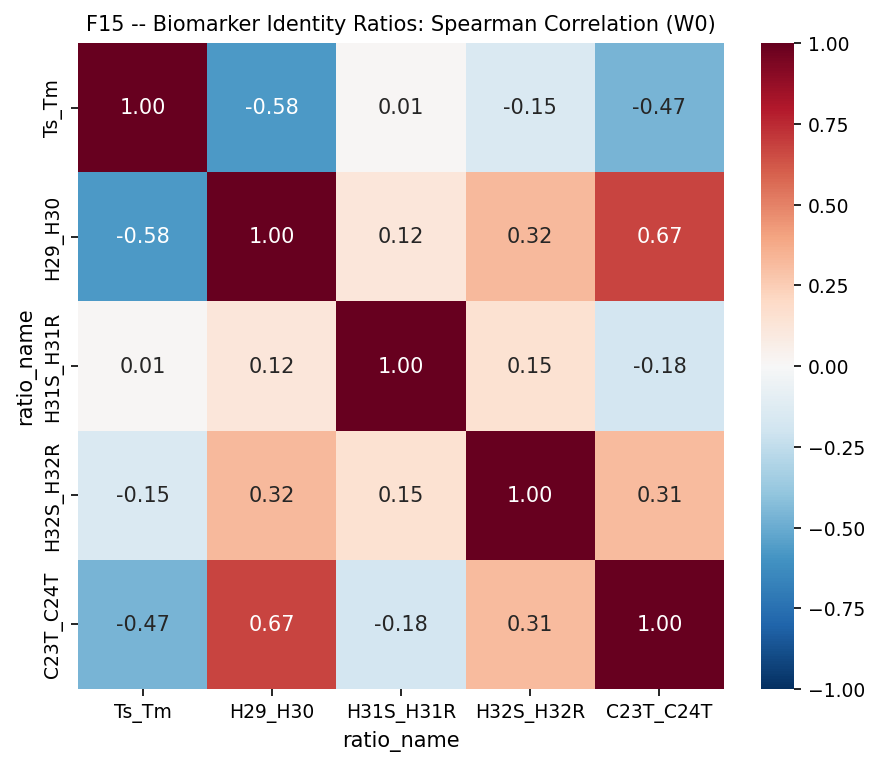

In [27]:
# B4 -- Correlation matrix at W0 between biomarker identity ratios
import seaborn as sns
w0_ratios_corr = df_ratios[df_ratios['stage'] == 'W0'].pivot_table(
    index='oil_id', columns='ratio_name', values='value')
w0_clean = w0_ratios_corr[IDENTITY_RATIOS].dropna(thresh=3, axis=1).dropna()

corr = w0_clean.corr(method='spearman')
print('Spearman correlation matrix (W0):')
print(corr.round(3).to_string())

print(f'\nPairs with |rho| > 0.95:')
found_redundant = False
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.95:
            print(f'  {corr.index[i]} x {corr.columns[j]}: rho = {corr.iloc[i, j]:.3f}')
            found_redundant = True
if not found_redundant:
    print('  None -- all pairs below 0.95')

# F15 -- Heatmap
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('F15 -- Biomarker Identity Ratios: Spearman Correlation (W0)', fontsize=10)
fig_path = FIG_DIR / 'F15_biomarker_ratio_correlation.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))


Forensic discrimination power (sigma_between / sigma_within):
    ratio  sigma_between  sigma_within  discrimination_power  n_oils
  H29_H30          0.878         0.011                78.773      49
    Ts_Tm          0.340         0.021                16.097      48
C23T_C24T          0.582         0.052                11.206      49
H31S_H31R          0.155         0.024                 6.507      46
H32S_H32R          0.168         0.028                 6.008      44

Values >> 10: ratio dominated by source signal, not weathering noise


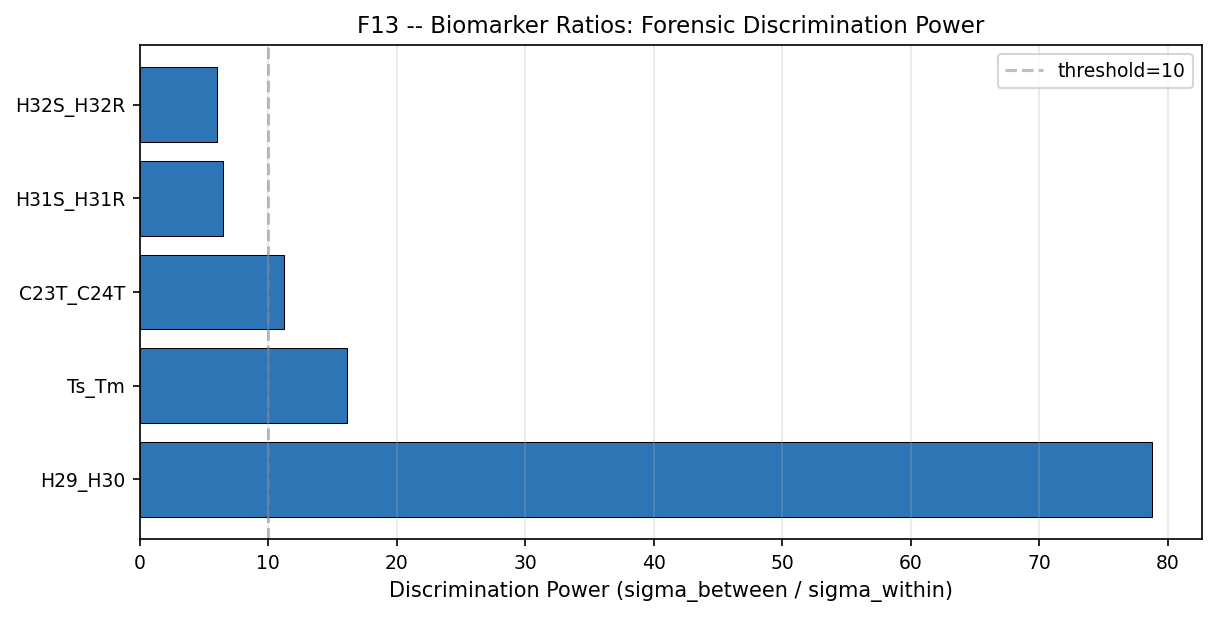

In [28]:
# B2 -- Forensic discrimination power: sigma_between / sigma_within
disc_results = []
for rname in IDENTITY_RATIOS:
    sub = df_ratios[df_ratios['ratio_name'] == rname].copy()
    oil_stats = sub.groupby('oil_id')['value'].agg(['mean', 'std', 'count'])
    oil_stats = oil_stats[oil_stats['count'] >= 3]
    sigma_within = oil_stats['std'].median()
    w0_vals = sub[sub['stage'] == 'W0']['value']
    sigma_between = w0_vals.std()
    disc_power = sigma_between / sigma_within if sigma_within > 0 else np.inf
    disc_results.append({
        'ratio': rname, 'sigma_between': sigma_between,
        'sigma_within': sigma_within, 'discrimination_power': disc_power,
        'n_oils': len(oil_stats),
    })

df_disc = pd.DataFrame(disc_results).sort_values('discrimination_power', ascending=False)
print('Forensic discrimination power (sigma_between / sigma_within):')
print(df_disc.to_string(index=False, float_format='%.3f'))
print(f'\nValues >> 10: ratio dominated by source signal, not weathering noise')

# F13 -- Bar chart
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.barh(df_disc['ratio'], df_disc['discrimination_power'], color='#2E75B6',
        edgecolor='k', linewidth=0.5)
ax.set_xlabel('Discrimination Power (sigma_between / sigma_within)', fontsize=10)
ax.set_title('F13 -- Biomarker Ratios: Forensic Discrimination Power', fontsize=11)
ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='threshold=10')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='x')
fig_path = FIG_DIR / 'F13_discrimination_power.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))


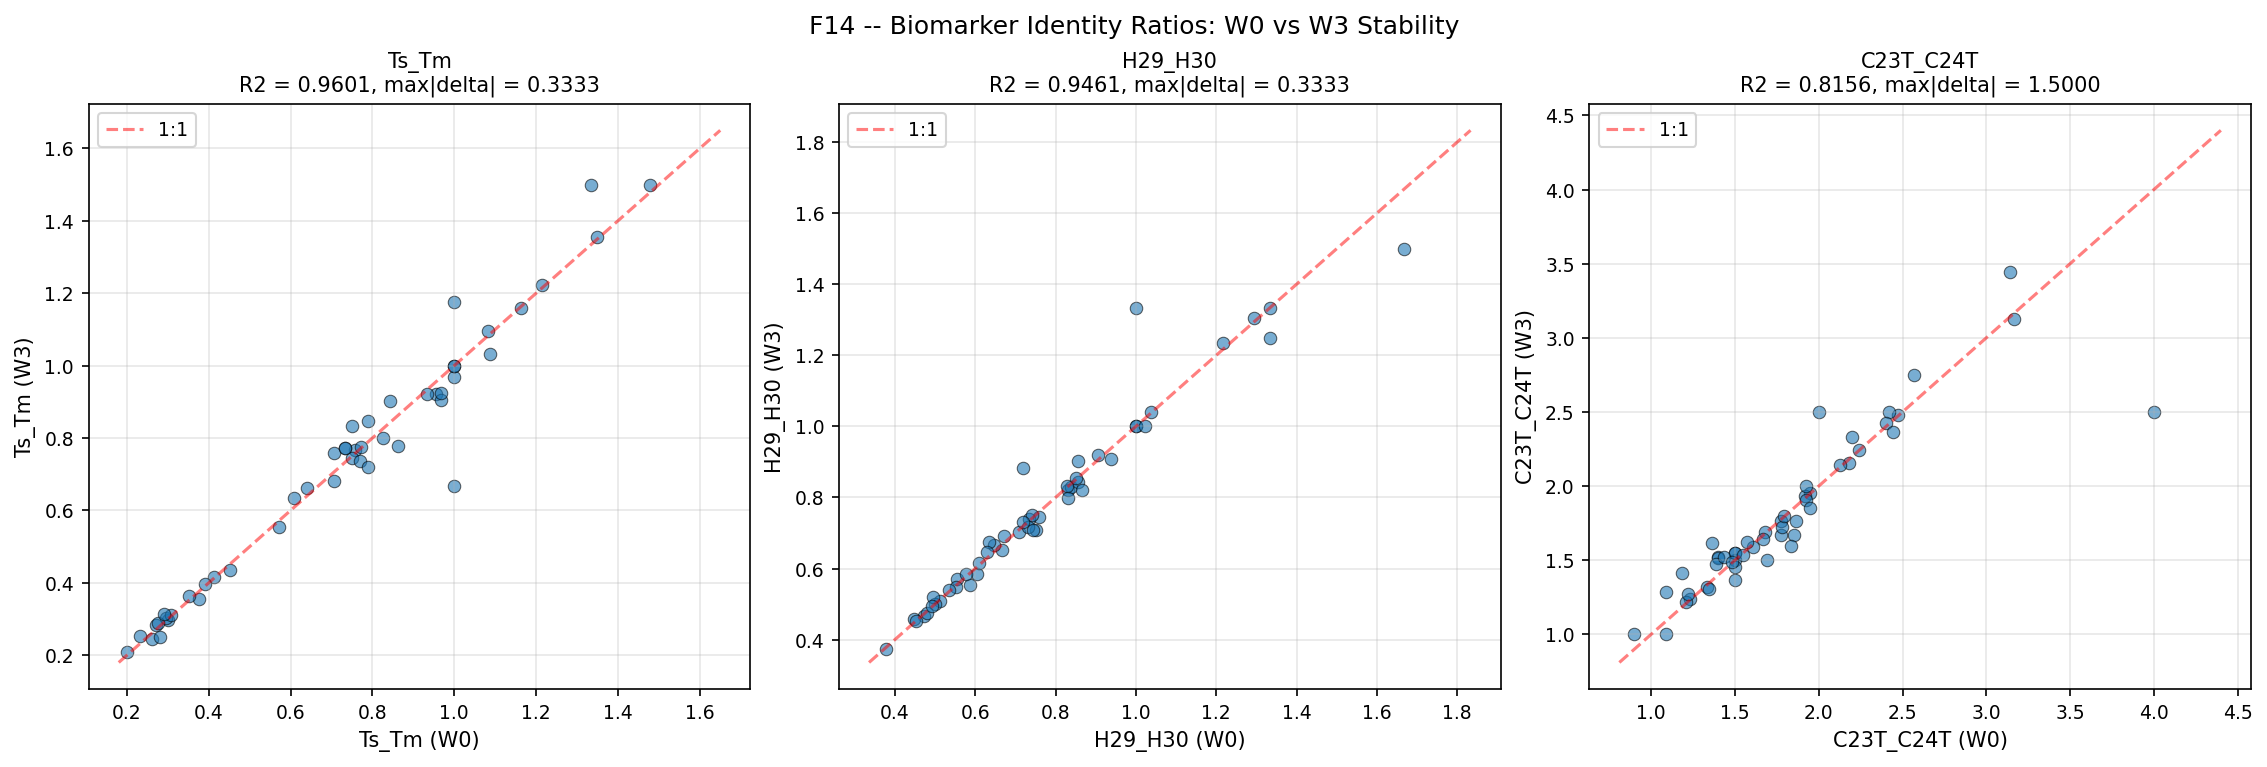

In [29]:
# B3 -- W0 vs W3 scatter for key identity ratios
from scipy.stats import pearsonr
key_ratios = ['Ts_Tm', 'H29_H30', 'C23T_C24T']

fig, axes = plt.subplots(1, len(key_ratios), figsize=(5*len(key_ratios), 5),
                         constrained_layout=True)
for ax, rname in zip(axes, key_ratios):
    sub = df_ratios[df_ratios['ratio_name'] == rname]
    w0 = sub[sub['stage'] == 'W0'].set_index('oil_id')['value']
    w3 = sub[sub['stage'] == 'W3'].set_index('oil_id')['value']
    common = w0.index.intersection(w3.index)
    if len(common) < 3:
        ax.set_title(f'{rname}\n(insufficient data)')
        continue
    ax.scatter(w0[common], w3[common], alpha=0.6, edgecolors='k', linewidth=0.5)
    lims = [min(w0[common].min(), w3[common].min()) * 0.9,
            max(w0[common].max(), w3[common].max()) * 1.1]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='1:1')
    r, _ = pearsonr(w0[common], w3[common])
    max_dev = (w3[common] - w0[common]).abs().max()
    ax.set_xlabel(f'{rname} (W0)', fontsize=10)
    ax.set_ylabel(f'{rname} (W3)', fontsize=10)
    ax.set_title(f'{rname}\nR2 = {r**2:.4f}, max|delta| = {max_dev:.4f}', fontsize=10)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('F14 -- Biomarker Identity Ratios: W0 vs W3 Stability', fontsize=12)
fig_path = FIG_DIR / 'F14_W0_vs_W3_scatter.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))


In [30]:
# B5 -- Inter-oil CV at W0 vs SHAP importance
cv_results = []
for rname in IDENTITY_RATIOS:
    w0_vals = df_ratios[(df_ratios['ratio_name'] == rname) &
                        (df_ratios['stage'] == 'W0')]['value'].dropna()
    cv = w0_vals.std() / w0_vals.mean() * 100 if w0_vals.mean() != 0 else np.nan
    cv_results.append({'ratio': rname, 'CV_W0_pct': cv, 'n': len(w0_vals)})

df_cv = pd.DataFrame(cv_results).sort_values('CV_W0_pct', ascending=False)
print('Inter-oil CV at W0 (%):')
print(df_cv.to_string(index=False, float_format='%.1f'))
print()
print('Interpretation: High CV = high source variability = high expected SHAP')
print('NB06 SHAP top-7 for C2 includes H31S_H31R and H32S_H32R')
print('Compare their CV ranking here with their SHAP ranking in NB06')


Inter-oil CV at W0 (%):
    ratio  CV_W0_pct  n
  H29_H30      102.4 58
    Ts_Tm       46.1 56
C23T_C24T       33.7 59
H32S_H32R       12.3 53
H31S_H31R       11.8 55

Interpretation: High CV = high source variability = high expected SHAP
NB06 SHAP top-7 for C2 includes H31S_H31R and H32S_H32R
Compare their CV ranking here with their SHAP ranking in NB06


In [31]:
# B6 -- Biomarker ratios vs API gravity (confounding check)
with get_conn() as conn:
    df_api = pd.read_sql("""
        SELECT oil_id, value AS api_gravity
        FROM sample_properties
        WHERE property_name = 'api_gravity'
          AND stage_code = 'W0'
    """, conn)

w0_ratios_api = df_ratios[df_ratios['stage'] == 'W0'].pivot_table(
    index='oil_id', columns='ratio_name', values='value')
w0_ratios_api = w0_ratios_api.join(df_api.set_index('oil_id'))
w0_ratios_api = w0_ratios_api.dropna(subset=['api_gravity'])

print('Spearman rho (biomarker ratio x API gravity, W0):')
confounds_found = False
for rname in IDENTITY_RATIOS:
    if rname in w0_ratios_api.columns:
        valid = w0_ratios_api[[rname, 'api_gravity']].dropna()
        if len(valid) > 5:
            rho, p = spearmanr(valid[rname], valid['api_gravity'])
            flag = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            warn = ' << CONFOUND' if abs(rho) > 0.5 else ''
            if abs(rho) > 0.5:
                confounds_found = True
            print(f'  {rname:15s}: rho = {rho:+.3f}, p = {p:.4f} {flag}{warn}')
if not confounds_found:
    print('\nNo confounding detected (all |rho| < 0.5)')


Spearman rho (biomarker ratio x API gravity, W0):
  Ts_Tm          : rho = +0.569, p = 0.0000 *** << CONFOUND
  H29_H30        : rho = -0.025, p = 0.8582 ns
  H31S_H31R      : rho = +0.020, p = 0.8860 ns
  H32S_H32R      : rho = +0.269, p = 0.0590 ns
  C23T_C24T      : rho = +0.148, p = 0.2748 ns


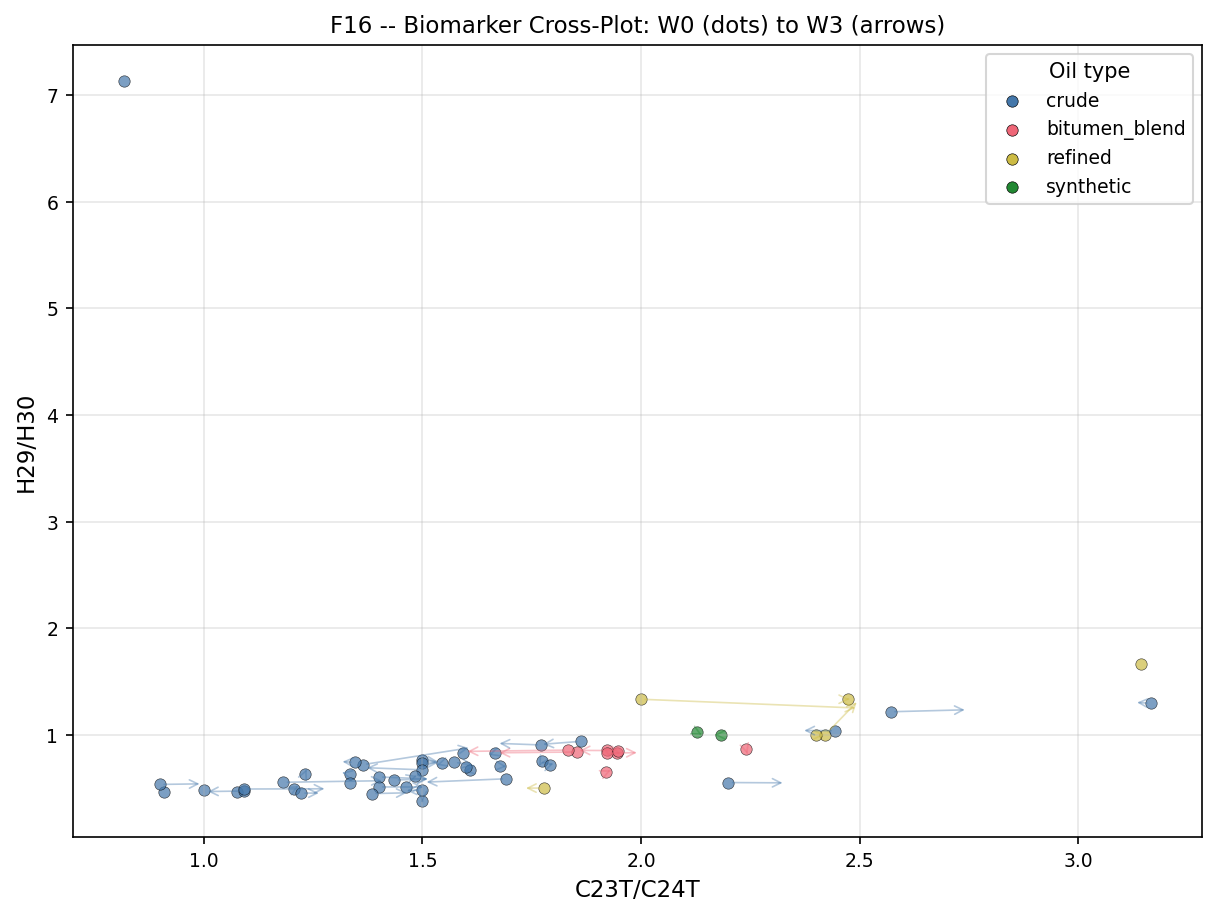

Arrow lengths (Euclidean): median=0.0510, max=0.5069


In [32]:
# B7 -- Cross-plot with W0->W3 arrows per oil
r1 = df_kw.iloc[0]['ratio'] if len(df_kw) >= 1 else 'C23T_C24T'
r2 = df_kw.iloc[1]['ratio'] if len(df_kw) >= 2 else 'H29_H30'

piv = df_ratios.pivot_table(index=['oil_id', 'stage'], columns='ratio_name',
                             values='value').reset_index()
with get_conn() as conn:
    oil_types_df = pd.read_sql('SELECT oil_id, oil_type FROM oils', conn)
piv = piv.merge(oil_types_df, on='oil_id')

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
arrow_lengths = []
for oil_id in piv['oil_id'].unique():
    od = piv[piv['oil_id'] == oil_id].dropna(subset=[r1, r2])
    w0d = od[od['stage'] == 'W0']
    w3d = od[od['stage'] == 'W3']
    if len(w0d) == 0:
        continue
    otype = od['oil_type'].iloc[0]
    color = OILTYPE_COLORS.get(otype, 'gray')
    ax.scatter(w0d[r1].values, w0d[r2].values, c=color, s=30,
               alpha=0.7, edgecolors='k', linewidth=0.3)
    if len(w3d) > 0:
        dx = w3d[r1].values[0] - w0d[r1].values[0]
        dy = w3d[r2].values[0] - w0d[r2].values[0]
        ax.annotate('', xy=(w3d[r1].values[0], w3d[r2].values[0]),
                    xytext=(w0d[r1].values[0], w0d[r2].values[0]),
                    arrowprops=dict(arrowstyle='->', color=color, alpha=0.4, lw=0.8))
        arrow_lengths.append(np.sqrt(dx**2 + dy**2))

for otype in OIL_TYPES_ML:
    ax.scatter([], [], c=OILTYPE_COLORS.get(otype, 'gray'), label=otype,
               s=30, edgecolors='k', linewidth=0.3)
ax.legend(title='Oil type', loc='best', fontsize=9)
ax.set_xlabel(r1.replace('_', '/'), fontsize=11)
ax.set_ylabel(r2.replace('_', '/'), fontsize=11)
ax.set_title(f'F16 -- Biomarker Cross-Plot: W0 (dots) to W3 (arrows)', fontsize=11)
ax.grid(alpha=0.3)
fig_path = FIG_DIR / 'F16_crossplot_arrows.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

if arrow_lengths:
    print(f'Arrow lengths (Euclidean): median={np.median(arrow_lengths):.4f}, '
          f'max={np.max(arrow_lengths):.4f}')


In [33]:
# C_FINAL -- Updated summary
print('NB03c3 SUMMARY (UPDATED)')
print('========================')
n_valid_compounds = len(df_change)
print(f'Biomarker compounds with valid data: {n_valid_compounds}/{len(ALL_BIOMARKERS)}')
print(f'Maturity: {df_mat["n_equilibrium"].min()}/{df_mat["n"].min()} oils at 22S/(22S+22R) equilibrium')
n_sig = (df_wilcox['p'] < alpha_bonf).sum()
print(f'Identity ratios significant after Bonferroni: {n_sig}/{len(IDENTITY_RATIOS)} (expected: 0)')
h30_cr = conc_ratio.median()
print(f'H30 concentration ratio (W3/W0): median = {h30_cr:.3f}')
if len(df_kw) > 0:
    best = df_kw.iloc[0]
    print(f'Best oil-type discriminator: {best["ratio"]} (KW p = {best["p"]:.2e})')
if len(df_disc) > 0:
    best_disc = df_disc.iloc[0]
    print(f'Best forensic discrimination power: {best_disc["ratio"]} '
          f'(sigma_between/sigma_within = {best_disc["discrimination_power"]:.1f})')
print(f'W0-W3 stability: confirmed via W0 vs W3 scatter (F14)')
print(f'Oleanane/Gammacerane: not in ECCC ESTS database')
print(f'\nFigures F01-F16 saved to: {FIG_DIR}')
print('Biomarkers confirmed as PURE IDENTITY MARKERS under ECCC ESTS protocol.')


NB03c3 SUMMARY (UPDATED)
Biomarker compounds with valid data: 21/21
Maturity: 43/53 oils at 22S/(22S+22R) equilibrium
Identity ratios significant after Bonferroni: 0/5 (expected: 0)
H30 concentration ratio (W3/W0): median = 1.278
Best oil-type discriminator: C23T_C24T (KW p = 8.69e-06)
Best forensic discrimination power: H29_H30 (sigma_between/sigma_within = 78.8)
W0-W3 stability: confirmed via W0 vs W3 scatter (F14)
Oleanane/Gammacerane: not in ECCC ESTS database

Figures F01-F16 saved to: C:\Users\leogr\Documents\Data Science\TCC\figures\nb03c3
Biomarkers confirmed as PURE IDENTITY MARKERS under ECCC ESTS protocol.
